In [1]:
# ============================================================
# AugTab multi-dataset Optuna tuner with mean ± std reporting
# ============================================================
import os, numpy as np, pandas as pd, optuna, torch, torch.nn as nn
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder


from AugTab import (
   AugTabClassifier, AugTabMulti, AugTabRegressor,
   RegularizerConfig, MLPBackbone, TinyProbe
)
try:
   from AugTab import EMATeacher
except Exception:
   EMATeacher = None


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED);
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)


# -------------------------
# Dataset list (file, target)
# -------------------------
DATASETS = [
   ("water_potability_cleaned.csv",   "Potability")
]


# If you *know* some tasks are regression, specify here; otherwise we auto-detect
FORCE_TASK = {
   # "air_quality_co.csv": "regression",
}


# -------------------------
# Helpers
# -------------------------
def n_trials_for_rows(n):
   """Heuristic: fewer trials for larger datasets."""
   if n <= 300:    return 120
   if n <= 1000:   return 80
   if n <= 5000:   return 60
   if n <= 20000:  return 40
   return 30


def load_and_prepare(csv_path, target):
   df = pd.read_csv(csv_path)
   # Basic clean: drop fully empty cols, simple NA impute later (via median for numeric)
   df = df.dropna(axis=1, how="all")
   y = df[target].copy()
   X = df.drop(columns=[target])


   # Encode non-numeric columns with get_dummies (safe for Adult etc.)
   X = pd.get_dummies(X, drop_first=False)
   # Fill NAs columnwise
   X = X.fillna(X.median(numeric_only=True))


   # y encoding for classification; for regression we keep numeric
   return X.astype(np.float32), y


def infer_task(y, forced=None):
   if forced is not None:
       return forced
   # If y is numeric with many unique values -> regression
   if pd.api.types.is_numeric_dtype(y):
       uniq = pd.unique(y)
       # integer but small unique -> classification, else regression
       if (pd.api.types.is_integer_dtype(y) and len(uniq) <= 20) or len(uniq) <= 10:
           return "classification"
       return "regression"
   return "classification"


# -------------------------
# Model builder (shares search space)
# -------------------------
def build_model(d, n_classes, task, trial):
   # FAL
   k_aug   = trial.suggest_categorical("k_aug",   [8,16,24,32,48,64,96])
   kprime  = trial.suggest_categorical("kprime",  [16,32,64,128])
   h_hid   = trial.suggest_categorical("h_hidden",[32,64,128,256])
   act     = trial.suggest_categorical("activation", ["gelu","relu","silu"])
   fal_do  = trial.suggest_float("fal_dropout", 0.0, 0.3)


   if task == "regression":
       gating = "basic"  # uncertainty gating is for classification; keep basic here
       tau, alpha, probe_layers, probe_hidden = 0.5, 1.0, 1, 64
   else:
       gating  = trial.suggest_categorical("gating", ["basic","uncertainty"])
       tau     = trial.suggest_float("tau", 0.35, 0.7) if gating=="uncertainty" else 0.5
       alpha   = trial.suggest_float("alpha", 0.3, 2.0) if gating=="uncertainty" else 1.0
       probe_layers = trial.suggest_categorical("probe_layers", [1,2]) if gating=="uncertainty" else 1
       probe_hidden = trial.suggest_categorical("probe_hidden", [16,32,64,128]) if gating=="uncertainty" else 64


   # Backbone
   depth = trial.suggest_categorical("depth", [1,2,3])
   width_choices = [64,128,192,256,384,512]
   widths = tuple(trial.suggest_categorical(f"w{i+1}", width_choices) for i in range(depth))
   bb_do = trial.suggest_float("bb_dropout", 0.0, 0.4)
   batchnorm = trial.suggest_categorical("batchnorm", [False, True])


   # Regularizers
   lam_sparse = trial.suggest_float("lambda_sparse", 1e-6, 1e-2, log=True)
   lam_div    = trial.suggest_float("lambda_div",    1e-6, 1e-2, log=True)
   lam_orth   = trial.suggest_float("lambda_orth",   1e-6, 1e-2, log=True)
   lam_budget = trial.suggest_float("lambda_budget", 1e-6, 1e-2, log=True)
   lam_drift  = trial.suggest_categorical("lambda_drift", [0.0, 1e-5, 1e-4, 1e-3])


   regs = RegularizerConfig(
       lambda_sparse=lam_sparse, lambda_div=lam_div, lambda_orth=lam_orth,
       lambda_budget=lam_budget, lambda_drift=lam_drift
   )


   # Training
   lr = trial.suggest_float("lr", 1e-4, 2e-2, log=True)
   wd = trial.suggest_float("weight_decay", 1e-6, 3e-3, log=True)
   bs = trial.suggest_categorical("batch_size", [32,64,128,256])
   epochs = trial.suggest_categorical("epochs", [80,120,160])
   patience = trial.suggest_categorical("patience", [10,20,30])


   # Build wrapper
   common_kwargs = dict(
       d_features=d, k_aug=k_aug, kprime=kprime, h_hidden=h_hid,
       widths=widths, activation=act, append_mask=False, gating=gating,
       regs=regs, device=DEVICE, lr=lr, weight_decay=wd
   )
   if task == "regression":
       model = AugTabRegressor(**common_kwargs)
   else:
       if n_classes <= 2:
           model = AugTabClassifier(**common_kwargs)
       else:
           model = AugTabMulti(n_classes=n_classes, **common_kwargs)


   # Inject searched dropouts / BN and rebuild backbone
   model.model.cfg.fal.dropout = fal_do
   model.model.fal.drop = nn.Dropout(fal_do) if fal_do > 0 else nn.Identity()
   model.model.cfg.backbone.dropout = bb_do
   model.model.cfg.backbone.batchnorm = batchnorm
   model.model.backbone = MLPBackbone(model.model.cfg.backbone).to(DEVICE)


   # Reset optimizer (new backbone)
   model.opt = torch.optim.AdamW(model.model.parameters(), lr=lr, weight_decay=wd)


   # Uncertainty extras
   if gating == "uncertainty" and task != "regression":
       model.model.cfg.fal.tau = tau
       model.model.cfg.fal.alpha = alpha
       model.model.cfg.fal.probe_layers = probe_layers
       model.model.cfg.fal.probe_hidden = probe_hidden
       model.model.fal.probe = TinyProbe(
           d_in=d if not model.model.cfg.append_mask else (d*2),
           n_classes=max(2, n_classes), hidden=probe_hidden,
           layers=probe_layers, act=act
       ).to(DEVICE)
       if getattr(model.model.fal.cfg, "margin_source", "probe") == "ema" and EMATeacher is not None:
           model.model.fal.ema_teacher = EMATeacher(model.model.fal.probe, decay=0.99)


   # controls
   model.fit_epochs   = epochs
   model.fit_patience = patience
   model.fit_batchsz  = bs
   return model


# -------------------------
# Objective factory
# -------------------------
def make_objective(X, y, task):
   # Encode y for classification
   if task == "classification":
       le = LabelEncoder()
       y = le.fit_transform(y)
       n_classes = len(le.classes_)
   else:
       n_classes = 1


   d = X.shape[1]


   def objective(trial):
       torch.manual_seed(SEED); np.random.seed(SEED)
       if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)


       model = build_model(d, n_classes, task, trial)
       if task == "regression":
           kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
       else:
           kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


       scores = []
       for tr, va in kf.split(X, y if task=="classification" else np.zeros(len(X))):
           Xtr, Xva = X[tr], X[va]
           ytr, yva = (y[tr], y[va]) if task=="classification" else (y.iloc[tr] if hasattr(y,'iloc') else y[tr],
                                                                     y.iloc[va] if hasattr(y,'iloc') else y[va])


           scaler = StandardScaler().fit(Xtr)
           Xtr = scaler.transform(Xtr).astype(np.float32)
           Xva = scaler.transform(Xva).astype(np.float32)


           model.fit(Xtr, ytr,
                     epochs=getattr(model, "fit_epochs", 120),
                     batch_size=getattr(model, "fit_batchsz", 128),
                     patience=getattr(model, "fit_patience", 20),
                     verbose=False)


           if task == "regression":
               # R^2
               scores.append(model.score(Xva, yva))
           else:
               if n_classes <= 2:
                   # tune threshold per fold for accuracy
                   with torch.no_grad():
                       p = model.predict_proba(Xva).numpy().reshape(-1)
                   best = 0.0
                   for t in np.linspace(0.3, 0.7, 21):
                       pred = (p >= t).astype(int)
                       best = max(best, (pred == yva).mean())
                   scores.append(best)
               else:
                   scores.append(model.score(Xva, yva))


       mean_s = float(np.mean(scores))
       std_s  = float(np.std(scores))
       trial.set_user_attr("cv_mean", mean_s)
       trial.set_user_attr("cv_std", std_s)
       trial.set_user_attr("fold_scores", [float(s) for s in scores])
       return mean_s


   return objective


# -------------------------
# Run all datasets
# -------------------------
results = []
for file, target in DATASETS:
   if not os.path.exists(file):
       print(f"  Skipping (not found): {file}")
       continue


   X, y = load_and_prepare(file, target)
   task = infer_task(y, FORCE_TASK.get(file))
   n = len(X)
   n_trials = n_trials_for_rows(n)
   direction = "maximize"  # accuracy or R^2


   print(f"\n=== {file} | rows={n} | task={task} | trials={n_trials} ===")
   study = optuna.create_study(direction=direction)
   study.optimize(make_objective(X.values if isinstance(X, pd.DataFrame) else X, y, task),
                  n_trials=n_trials, show_progress_bar=True)


   bt = study.best_trial
   mean = bt.user_attrs.get("cv_mean", bt.value)
   std  = bt.user_attrs.get("cv_std", float("nan"))


   metric_name = "Acc" if task=="classification" else "R2"
   print(f"Best {metric_name}: {mean:.4f} ± {std:.4f}")
   results.append({
       "Dataset": file,
       "Rows": n,
       "Task": task,
       f"CV_{metric_name}_Mean": mean,
       f"CV_{metric_name}_Std": std,
       "BestParams": study.best_params
   })


# Show & save summary
summary = pd.DataFrame(results)
display(summary)
summary.to_csv("AugTab_multi_dataset_results.csv", index=False)
print("\nSaved: AugTab_multi_dataset_results.csv")

[I 2026-03-09 16:36:06,711] A new study created in memory with name: no-name-867a90d6-6fef-4ef2-b0aa-eeda5159abb3



=== water_potability_cleaned.csv | rows=3276 | task=classification | trials=60 ===


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-03-09 16:50:58,321] Trial 0 finished with value: 0.7094102587972444 and parameters: {'k_aug': 32, 'kprime': 16, 'h_hidden': 32, 'activation': 'relu', 'fal_dropout': 0.2875146907283646, 'gating': 'basic', 'depth': 1, 'w1': 64, 'bb_dropout': 0.09373596316218072, 'batchnorm': False, 'lambda_sparse': 4.6499291653764965e-05, 'lambda_div': 0.00016761505599055678, 'lambda_orth': 0.00010944592524572554, 'lambda_budget': 2.0838449063597157e-06, 'lambda_drift': 1e-05, 'lr': 0.00015635803102405455, 'weight_decay': 0.00148271598009157, 'batch_size': 32, 'epochs': 160, 'patience': 10}. Best is trial 0 with value: 0.7094102587972444.
[I 2026-03-09 16:58:37,813] Trial 1 finished with value: 0.719794265499907 and parameters: {'k_aug': 48, 'kprime': 128, 'h_hidden': 64, 'activation': 'relu', 'fal_dropout': 0.2841399795718271, 'gating': 'basic', 'depth': 1, 'w1': 512, 'bb_dropout': 0.012624340463725715, 'batchnorm': False, 'lambda_sparse': 0.0003733696527395378, 'lambda_div': 1.9139521943506727e

,Dataset,Rows,Task,CV_Acc_Mean,CV_Acc_Std,BestParams
0,water_potability_cleaned.csv,3276,classification,0.880408,0.118458,"{'k_aug': 96, 'kprime': 32, 'h_hidden': 128, '..."



Saved: AugTab_multi_dataset_results.csv


# tSNE

In [2]:
# ============================================================
# AugTab t-SNE visualization
#   1) sample embeddings
#   2) feature proxy embeddings
# ============================================================
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ------------------------------------------------------------
# 1) Rebuild and train best AugTab model on a train/test split
# ------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- load your dataset again (or reuse X, y from earlier) ----
file = "water_potability_cleaned.csv"
target = "Potability"

df = pd.read_csv(file).dropna(axis=1, how="all")
y_raw = df[target].copy()
X_df = df.drop(columns=[target])

# same preprocessing used in tuning
X_df = pd.get_dummies(X_df, drop_first=False)
X_df = X_df.fillna(X_df.median(numeric_only=True))
X_df = X_df.astype(np.float32)

# classification labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
n_classes = len(le.classes_)

# split
X_tr_df, X_te_df, y_tr, y_te = train_test_split(
    X_df, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# scale
scaler = StandardScaler().fit(X_tr_df.values)
X_tr = scaler.transform(X_tr_df.values).astype(np.float32)
X_te = scaler.transform(X_te_df.values).astype(np.float32)

d = X_tr.shape[1]

# ------------------------------------------------------------
# Use best params from Optuna
# ------------------------------------------------------------
best_params = study.best_trial.params.copy()   # assumes your Optuna study exists

# build model using your earlier helper
best_model = build_model(
    d=d,
    n_classes=n_classes,
    task="classification",
    trial=type("DummyTrial", (), {
        "suggest_categorical": lambda self, name, choices: best_params[name],
        "suggest_float": lambda self, name, low, high, log=False: best_params[name]
    })()
)

# fit on split
best_model.fit(
    X_tr, y_tr,
    epochs=getattr(best_model, "fit_epochs", 120),
    batch_size=getattr(best_model, "fit_batchsz", 128),
    patience=getattr(best_model, "fit_patience", 20),
    verbose=False
)

# Sample embeddings for tSNE for AugTab

In [3]:
# ============================================================
# Helper: get per-sample latent reps from AugTab
# ============================================================
def get_augtab_sample_reps(wrapper_model, X):
    """
    Extract per-sample latent representations from AugTab.
    Priority:
      1) input to final classifier head
      2) output of backbone
      3) fallback to final model output

    Returns:
      reps: numpy array of shape (n_samples, d_rep)
    """
    net = wrapper_model.model
    net.eval()

    if isinstance(X, pd.DataFrame):
        X_arr = X.values.astype(np.float32)
    else:
        X_arr = np.asarray(X, dtype=np.float32)

    Xt = torch.tensor(X_arr, dtype=torch.float32, device=wrapper_model.device)

    captured = {}

    # ---------- find likely classifier head ----------
    candidate_heads = []
    for name, mod in net.named_modules():
        if isinstance(mod, nn.Linear):
            candidate_heads.append((name, mod))

    # prefer linears with out_features == n_classes or 1
    preferred = []
    for name, mod in candidate_heads:
        if mod.out_features in [1, 2, getattr(wrapper_model, "n_classes", 2)]:
            preferred.append((name, mod))

    target_head = preferred[-1][1] if len(preferred) > 0 else (candidate_heads[-1][1] if candidate_heads else None)

    hook_handle = None

    if target_head is not None:
        def hook_fn(module, inputs, output):
            # capture input to final linear layer
            z = inputs[0]
            captured["reps"] = z.detach().cpu()

        hook_handle = target_head.register_forward_hook(hook_fn)

    with torch.no_grad():
        try:
            _ = net(Xt)
        except Exception:
            # some wrappers may expose the torch model differently
            if hook_handle is not None:
                hook_handle.remove()
            raise

    if hook_handle is not None:
        hook_handle.remove()

    # 1) preferred: input to final classifier head
    if "reps" in captured:
        reps = captured["reps"].numpy()
        if reps.ndim == 1:
            reps = reps[:, None]
        return reps

    # 2) fallback: try backbone output directly
    if hasattr(net, "backbone"):
        with torch.no_grad():
            try:
                # try using FAL then backbone
                if hasattr(net, "fal"):
                    z = net.fal(Xt)
                    if isinstance(z, tuple):
                        z = z[0]
                    z = net.backbone(z)
                else:
                    z = net.backbone(Xt)

                reps = z.detach().cpu().numpy()
                if reps.ndim == 1:
                    reps = reps[:, None]
                return reps
            except Exception:
                pass

    # 3) final fallback: use model output
    with torch.no_grad():
        out = net(Xt)
        if isinstance(out, tuple):
            out = out[0]
        reps = out.detach().cpu().numpy()
        if reps.ndim == 1:
            reps = reps[:, None]
        return reps

Sample embeddings shape: (656, 384) | Labels shape: (656,)
Using perplexity = 30 for t-SNE (n_samples = 656)


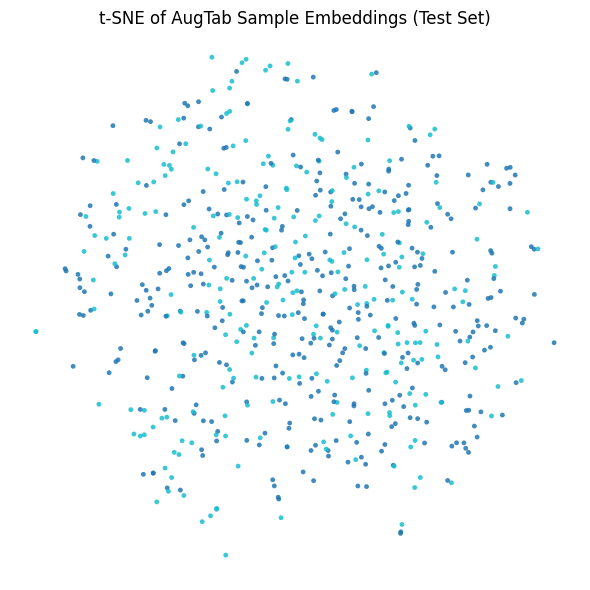

In [4]:
# ============================================================
# t-SNE of AugTab sample embeddings
# ============================================================
sample_embs = get_augtab_sample_reps(best_model, X_te)
labels = np.asarray(y_te)

print("Sample embeddings shape:", sample_embs.shape, "| Labels shape:", labels.shape)

n_samples = sample_embs.shape[0]
perplexity = max(5, min(30, (n_samples - 1) // 3))
print(f"Using perplexity = {perplexity} for t-SNE (n_samples = {n_samples})")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=200,
    random_state=42,
    init="pca",
)

Z_2d = tsne.fit_transform(sample_embs)

plt.figure(figsize=(6, 6))
plt.scatter(
    Z_2d[:, 0], Z_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=12,
    alpha=0.85,
    edgecolors="none",
)
plt.axis("off")
plt.title("t-SNE of AugTab Sample Embeddings (Test Set)")
plt.tight_layout()
plt.savefig("tsne_augtab_samples.png", dpi=600, bbox_inches="tight")
plt.savefig("tsne_augtab_samples.pdf", bbox_inches="tight")
plt.show()

# Feature level embeddings tSNE for AugTab

Feature proxy embeddings shape: (9, 288)
Using perplexity = 5 for t-SNE (m = 9)


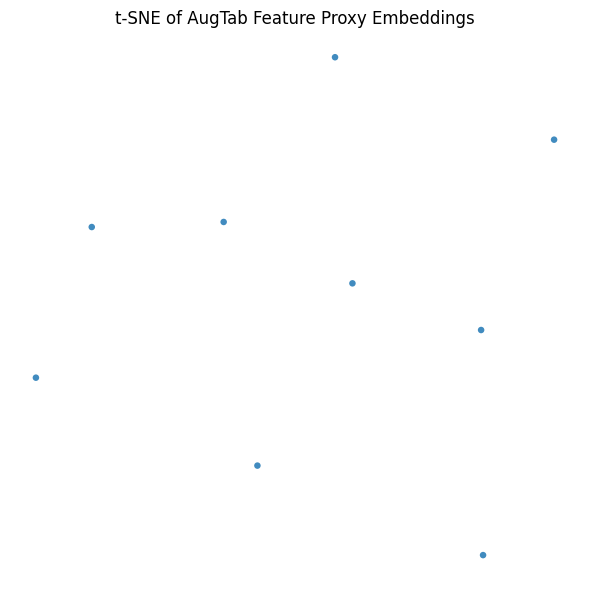

In [5]:
# ============================================================
# Helper: proxy per-feature embeddings for AugTab
# ============================================================
def get_augtab_feature_proxy_embeddings(wrapper_model, d_expected):
    """
    Build a proxy embedding for each original input feature.

    Strategy:
      - collect all Linear layers with in_features == number of original features
      - for each layer, use each input feature's column weights as a feature vector
      - concatenate across layers

    Returns:
      feat_embs: (n_features, dim_proxy)
    """
    net = wrapper_model.model
    blocks = []

    for name, mod in net.named_modules():
        if isinstance(mod, nn.Linear) and mod.in_features == d_expected:
            W = mod.weight.detach().cpu().numpy()   # (out_features, d)
            blocks.append(W.T)                      # (d, out_features)

    if len(blocks) == 0:
        raise RuntimeError(
            f"No Linear layer found with in_features == {d_expected}. "
            "AugTab internals may differ; inspect model.model.named_modules()."
        )

    feat_embs = np.concatenate(blocks, axis=1)     # (d, total_dim)
    return feat_embs


feature_embs = get_augtab_feature_proxy_embeddings(best_model, d_expected=d)

print("Feature proxy embeddings shape:", feature_embs.shape)

m = feature_embs.shape[0]
perplexity = max(5, min(30, (m - 1) // 3))
print(f"Using perplexity = {perplexity} for t-SNE (m = {m})")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=200,
    random_state=42,
    init="pca",
)
F_2d = tsne.fit_transform(feature_embs)

feat_names = list(X_tr_df.columns)

plt.figure(figsize=(6, 6))
plt.scatter(
    F_2d[:, 0], F_2d[:, 1],
    s=22,
    alpha=0.85,
    edgecolors="none",
)

# Optional tiny labels:
# for j, name in enumerate(feat_names):
#     plt.text(F_2d[j, 0], F_2d[j, 1], name, fontsize=5, alpha=0.7)

plt.axis("off")
plt.title("t-SNE of AugTab Feature Proxy Embeddings")
plt.tight_layout()
plt.savefig("tsne_augtab_features.png", dpi=600, bbox_inches="tight")
plt.savefig("tsne_augtab_features.pdf", bbox_inches="tight")
plt.show()

# Inference Level Diagnostics for Robustness and Calibration

[INFO] Using AugTab model on device=cuda
[INFO] Test batches: 3
[INFO] Test shape: X=(656, 9), y=(656,)


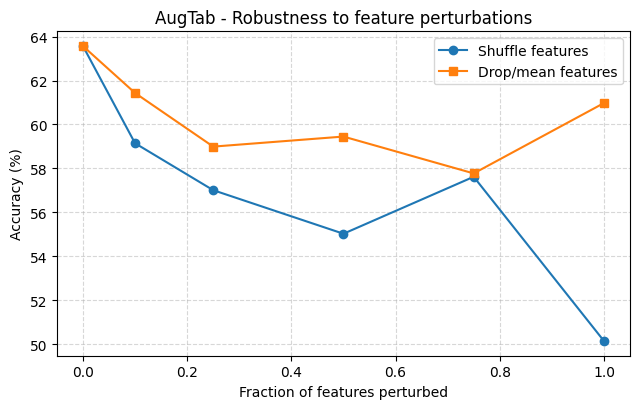

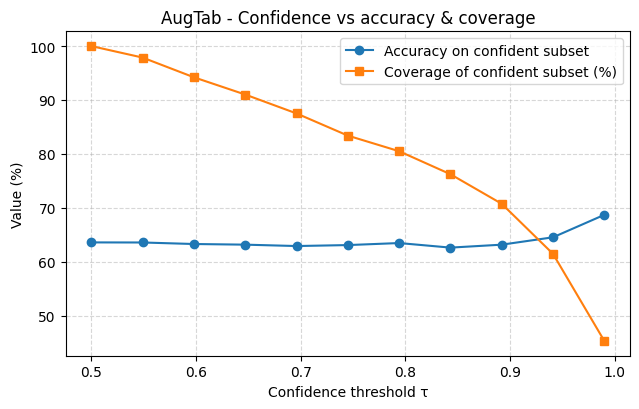

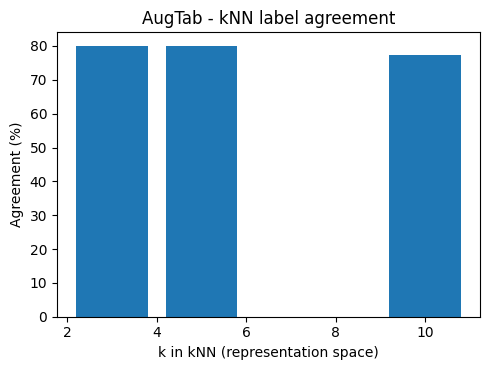

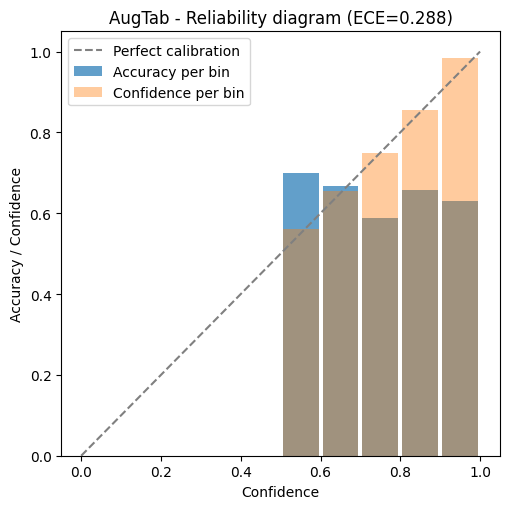


=== AugTab Inference Ablation Summary (Test Set) ===
      Tab Shuffle ↓  Tab Drop ↓  kNN-Agree@5 (%)
0.00          63.57       63.57            79.94
0.10          59.15       61.43            79.94
0.25          57.01       58.99            79.94
0.50          55.03       59.45            79.94
0.75          57.62       57.77            79.94
1.00          50.15       60.98            79.94

Expected Calibration Error (ECE): 0.288


In [7]:
# ============================================================
# AugTab inference-level diagnostics 
#  - Robustness to feature perturbations
#  - Confidence vs accuracy / coverage
#  - kNN consistency in representation space
#  - Calibration: reliability diagram + ECE
#
# Requires:
#   best_model  : trained AugTab wrapper
#   X_te        : test features (numpy array or pandas DataFrame)
#   y_te        : test labels (numpy array or pandas Series)
#   best_params : optional dict from Optuna best trial
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ------------------------------------------------------------
# Prepare test arrays / loader
# ------------------------------------------------------------
if isinstance(X_te, pd.DataFrame):
    X_te_arr = X_te.values.astype(np.float32)
else:
    X_te_arr = np.asarray(X_te, dtype=np.float32)

if isinstance(y_te, pd.Series):
    y_te_arr = y_te.to_numpy()
else:
    y_te_arr = np.asarray(y_te)

y_te_arr = y_te_arr.astype(int)

batch_size = best_params.get("batch_size", 64) if "best_params" in globals() else 64

ds_test = TensorDataset(
    torch.tensor(X_te_arr, dtype=torch.float32),
    torch.tensor(y_te_arr, dtype=torch.long),
)
loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

model = best_model
device = model.device if hasattr(model, "device") else ("cuda" if torch.cuda.is_available() else "cpu")
model.model.eval()

print(f"[INFO] Using AugTab model on device={device}")
print(f"[INFO] Test batches: {len(loader)}")
print(f"[INFO] Test shape: X={X_te_arr.shape}, y={y_te_arr.shape}")


# ------------------------------------------------------------
# Helper: find final linear head
# ------------------------------------------------------------
def find_final_linear_head(net):
    linears = []
    for name, mod in net.named_modules():
        if isinstance(mod, nn.Linear):
            linears.append((name, mod))
    if len(linears) == 0:
        raise RuntimeError("No nn.Linear layer found in AugTab model.")
    return linears[-1][0], linears[-1][1]


# ------------------------------------------------------------
# Helper: extract per-sample latent reps from AugTab
# ------------------------------------------------------------
@torch.no_grad()
def get_augtab_sample_reps(wrapper_model, X_np):
    """
    Capture the input to the final prediction head as the
    per-sample latent representation.
    """
    net = wrapper_model.model
    net.eval()

    Xt = torch.tensor(X_np, dtype=torch.float32, device=wrapper_model.device)

    _, head_mod = find_final_linear_head(net)
    captured = []

    def hook_fn(module, inputs, output):
        z = inputs[0]
        captured.append(z.detach().cpu())

    h = head_mod.register_forward_hook(hook_fn)
    _ = net(Xt)
    h.remove()

    if len(captured) == 0:
        raise RuntimeError("Failed to capture AugTab latent representations.")

    reps = torch.cat(captured, dim=0).numpy()
    if reps.ndim == 1:
        reps = reps[:, None]
    return reps


# ------------------------------------------------------------
# Helper: probabilities from AugTab wrapper
# ------------------------------------------------------------
@torch.no_grad()
def augtab_predict_proba_numpy(wrapper_model, X_np):
    out = wrapper_model.predict_proba(X_np)

    if isinstance(out, torch.Tensor):
        probs = out.detach().cpu().numpy()
    else:
        probs = np.asarray(out)

    # binary case: shape (N,) or (N,1) -> convert to (N,2)
    if probs.ndim == 1:
        probs_pos = probs.reshape(-1, 1)
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)
    elif probs.ndim == 2 and probs.shape[1] == 1:
        probs_pos = probs
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)

    # normalize just in case
    row_sums = probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    probs = probs / row_sums

    return probs


# ------------------------------------------------------------
# Core prediction helper
# ------------------------------------------------------------
@torch.no_grad()
def predict_loader_augtab(loader, perturb=None):
    probs_all, preds_all, y_all, embs_all = [], [], [], []

    for xb, yb in loader:
        xb_np = xb.numpy().astype(np.float32)

        if perturb is not None:
            xb_np = perturb(xb_np)

        probs = augtab_predict_proba_numpy(model, xb_np)
        preds = probs.argmax(axis=1)
        embs  = get_augtab_sample_reps(model, xb_np)

        probs_all.append(probs)
        preds_all.append(preds)
        y_all.append(yb.numpy())
        embs_all.append(embs)

    probs = np.concatenate(probs_all, axis=0)
    preds = np.concatenate(preds_all, axis=0)
    y     = np.concatenate(y_all, axis=0)
    embs  = np.concatenate(embs_all, axis=0)

    return probs, preds, y, embs


# ------------------------------------------------------------
# Tabular perturbations
# ------------------------------------------------------------
def make_feature_shuffle_perturber(p, rng_seed=42):
    rng = np.random.default_rng(rng_seed)

    def _perturb(xb):
        xb = xb.copy()
        B, m = xb.shape
        k = int(round(p * m))
        if k > 0:
            cols = rng.choice(m, size=k, replace=False)
            for c in cols:
                perm = rng.permutation(B)
                xb[:, c] = xb[perm, c]
        return xb

    return _perturb


def make_feature_drop_perturber(p):
    def _perturb(xb):
        xb = xb.copy()
        B, m = xb.shape
        k = int(round(p * m))
        if k > 0:
            cols = np.random.choice(m, size=k, replace=False)
            col_means = xb.mean(axis=0, keepdims=True)
            xb[:, cols] = col_means[:, cols]
        return xb

    return _perturb


# ------------------------------------------------------------
# 1. Robustness to feature perturbations
# ------------------------------------------------------------
ps = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]

def eval_accuracy(loader, perturb=None):
    _, preds, y, _ = predict_loader_augtab(loader, perturb)
    return accuracy_score(y, preds) * 100.0

acc_shuffle = [eval_accuracy(loader, make_feature_shuffle_perturber(p)) for p in ps]
acc_drop    = [eval_accuracy(loader, make_feature_drop_perturber(p))    for p in ps]

plt.figure(figsize=(6.5, 4.2))
plt.plot(ps, acc_shuffle, '-o', label='Shuffle features')
plt.plot(ps, acc_drop,    '-s', label='Drop/mean features')
plt.xlabel("Fraction of features perturbed")
plt.ylabel("Accuracy (%)")
plt.title("AugTab - Robustness to feature perturbations")
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("augtab_robustness_tabular.png", dpi=600, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 2. Confidence vs accuracy / coverage + kNN agreement
# ------------------------------------------------------------
probs, preds, y, embs = predict_loader_augtab(loader)
conf = probs.max(axis=1)

taus = np.linspace(0.5, 0.99, 11)

idx_conf = [np.where(conf >= t)[0] for t in taus]
acc_conf = [
    accuracy_score(y[idx], preds[idx]) * 100.0 if len(idx) > 0 else np.nan
    for idx in idx_conf
]
ratio_conf = [len(idx) / len(y) * 100.0 for idx in idx_conf]

# kNN agreement in learned representation space
n_neighbors = min(11, len(embs))
nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean').fit(embs)
neigh = nbrs.kneighbors(embs, return_distance=False)

# remove self if present in first position
if neigh.shape[1] > 1:
    neigh = neigh[:, 1:]
else:
    neigh = neigh[:, :0]

agree = []
for k in [3, 5, 10]:
    k_eff = min(k, neigh.shape[1])
    if k_eff == 0:
        agree.append(np.nan)
        continue
    a = [(preds[neigh[i, :k_eff]] == preds[i]).mean() for i in range(len(y))]
    agree.append(100.0 * np.mean(a))

plt.figure(figsize=(6.5, 4.2))
plt.plot(taus, acc_conf,   '-o', label='Accuracy on confident subset')
plt.plot(taus, ratio_conf, '-s', label='Coverage of confident subset (%)')
plt.xlabel("Confidence threshold τ")
plt.ylabel("Value (%)")
plt.title("AugTab - Confidence vs accuracy & coverage")
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("augtab_confidence_curve.png", dpi=600, bbox_inches='tight')
plt.show()

plt.figure(figsize=(5, 3.8))
plt.bar([3, 5, 10], agree, width=1.6)
plt.xlabel("k in kNN (representation space)")
plt.ylabel("Agreement (%)")
plt.title("AugTab - kNN label agreement")
plt.tight_layout()
plt.savefig("augtab_knn_agreement.png", dpi=600, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 3. Calibration: reliability diagram + ECE
# ------------------------------------------------------------
bins = np.linspace(0.0, 1.0, 11)
bin_ids = np.digitize(conf, bins) - 1
bin_ids = np.clip(bin_ids, 0, len(bins) - 2)

acc_bin, conf_bin, cnt_bin = [], [], []

for b in range(len(bins) - 1):
    idx = np.where(bin_ids == b)[0]
    if len(idx) == 0:
        acc_bin.append(0.0)
        conf_bin.append(0.0)
        cnt_bin.append(0)
    else:
        acc_bin.append(accuracy_score(y[idx], preds[idx]))
        conf_bin.append(conf[idx].mean())
        cnt_bin.append(len(idx))

acc_bin  = np.array(acc_bin)
conf_bin = np.array(conf_bin)
cnt_bin  = np.array(cnt_bin)

ece = np.sum(np.abs(acc_bin - conf_bin) * (cnt_bin / len(y)))

plt.figure(figsize=(5.2, 5.2))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.bar(bins[:-1] + 0.05, acc_bin,  width=0.09, alpha=0.7, label='Accuracy per bin')
plt.bar(bins[:-1] + 0.05, conf_bin, width=0.09, alpha=0.4, label='Confidence per bin')
plt.xlabel("Confidence")
plt.ylabel("Accuracy / Confidence")
plt.title(f"AugTab - Reliability diagram (ECE={ece:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("augtab_reliability.png", dpi=600, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 4. Summary table
# ------------------------------------------------------------
df_summary = pd.DataFrame({
    "Tab Shuffle ↓": acc_shuffle,
    "Tab Drop ↓":    acc_drop,
}, index=[f"{p:.2f}" for p in ps])

df_summary["kNN-Agree@5 (%)"] = agree[1]

print("\n=== AugTab Inference Ablation Summary (Test Set) ===")
print(df_summary.round(2))
print(f"\nExpected Calibration Error (ECE): {ece:.3f}")

# Sanity and Stress Diagnostics

[INFO] Extra tests using AugTab on device=cuda
[INFO] Test batches: 3
[INFO] Test shape: X=(656, 9), y=(656,)

[Mode: full]
  Accuracy =  63.57%  (n=656)

[Mode: zero]
  Accuracy =  60.98%  (n=656)

[Mode: mean]
  Accuracy =  60.98%  (n=656)

[Mode: shuffle_rows]
  Accuracy =  53.81%  (n=656)

[Mode: heavy_noise]
  Accuracy =  57.93%  (n=656)


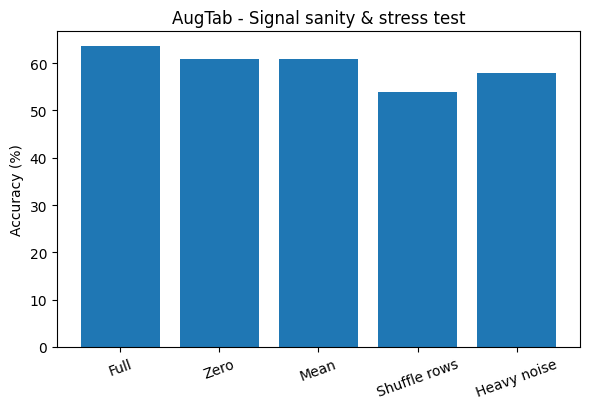


=== Augmentation consistency / stress (AugTab) ===
Base accuracy:  63.57%
TTA majority-vote accuracy (n_aug=5):  62.35%
Fraction of samples with any label change across aug:  41.62%


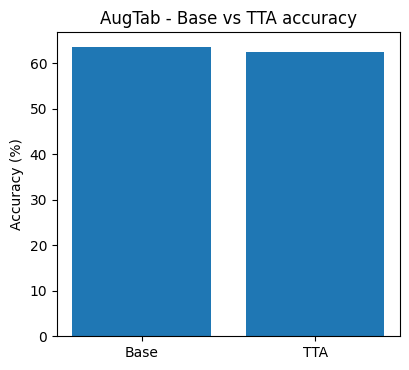


=== Per-class accuracy summary (AugTab, sorted by support) ===
   class_id  support  accuracy
0         0      400     76.00
1         1      256     44.14

=== Bucketed per-class accuracy (AugTab, by support) ===
        count   mean
bucket              
head        1  76.00
tail        1  44.14


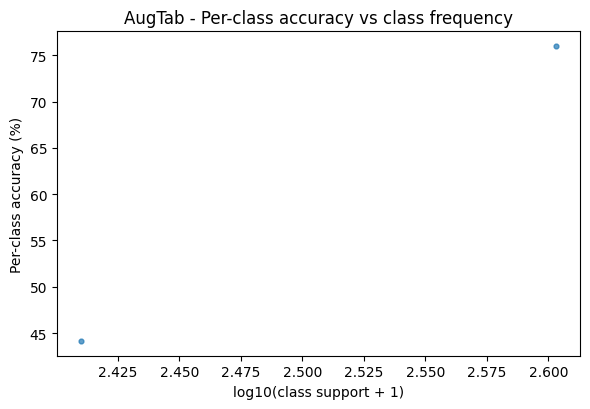


=== Signal sanity / stress summary (AugTab) ===
           mode  accuracy
0          full     63.57
1          zero     60.98
2          mean     60.98
3  shuffle_rows     53.81
4   heavy_noise     57.93

[Done] Extra sanity & stress tests (AugTab) complete.
Saved figures:
  - augtab_signal_sanity_stress.png
  - augtab_tta_accuracy.png
  - augtab_per_class_accuracy.png


In [8]:
# ============================================================
# Extra sanity & stress diagnostics for AugTab (single script)
#   1) Signal sanity / stress modes
#   2) Augmentation consistency / TTA stress test
#   3) Per-class accuracy vs class frequency
#
# Requires:
#   - best_model
#   - X_te
#   - y_te
#   - optionally best_params
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})


# ------------------------------------------------------------
# Prepare test arrays / loader
# ------------------------------------------------------------
if isinstance(X_te, pd.DataFrame):
    X_te_arr = X_te.values.astype(np.float32)
else:
    X_te_arr = np.asarray(X_te, dtype=np.float32)

if isinstance(y_te, pd.Series):
    y_te_arr = y_te.to_numpy()
else:
    y_te_arr = np.asarray(y_te)

y_te_arr = y_te_arr.astype(int)

batch_size = best_params.get("batch_size", 64) if "best_params" in globals() else 64

ds_test = TensorDataset(
    torch.tensor(X_te_arr, dtype=torch.float32),
    torch.tensor(y_te_arr, dtype=torch.long),
)
loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

model = best_model
device = model.device if hasattr(model, "device") else ("cuda" if torch.cuda.is_available() else "cpu")
model.model.eval()

print(f"[INFO] Extra tests using AugTab on device={device}")
print(f"[INFO] Test batches: {len(loader)}")
print(f"[INFO] Test shape: X={X_te_arr.shape}, y={y_te_arr.shape}")


# ------------------------------------------------------------
# Helper: predict probabilities from AugTab
# ------------------------------------------------------------
@torch.no_grad()
def augtab_predict_proba_numpy(wrapper_model, X_np):
    """
    Returns class probabilities as numpy array.
    Handles binary and multiclass output.
    """
    out = wrapper_model.predict_proba(X_np)

    if isinstance(out, torch.Tensor):
        probs = out.detach().cpu().numpy()
    else:
        probs = np.asarray(out)

    # Binary case: shape (N,) or (N,1) -> convert to (N,2)
    if probs.ndim == 1:
        probs_pos = probs.reshape(-1, 1)
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)
    elif probs.ndim == 2 and probs.shape[1] == 1:
        probs_pos = probs
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)

    # Normalize just in case
    row_sums = probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    probs = probs / row_sums

    return probs


# ------------------------------------------------------------
# Core prediction helper
# ------------------------------------------------------------
@torch.no_grad()
def predict_loader_augtab(loader, perturb=None):
    """
    Returns:
      probs : (N, C)
      preds : (N,)
      y     : (N,)
    """
    probs_all, preds_all, y_all = [], [], []

    for xb, yb in loader:
        xb_np = xb.numpy().astype(np.float32)

        if perturb is not None:
            xb_np = perturb(xb_np)

        probs = augtab_predict_proba_numpy(model, xb_np)
        preds = probs.argmax(axis=1)

        probs_all.append(probs)
        preds_all.append(preds)
        y_all.append(yb.numpy())

    probs = np.concatenate(probs_all, axis=0)
    preds = np.concatenate(preds_all, axis=0)
    y     = np.concatenate(y_all, axis=0)

    return probs, preds, y


# ============================================================
# 1. Signal sanity & stress tests
#    Modes:
#      - full
#      - zero
#      - mean
#      - shuffle_rows
#      - heavy_noise
# ============================================================
def make_signal_perturber(mode, X_stats=None):
    """
    mode ∈ {"full", "zero", "mean", "shuffle_rows", "heavy_noise"}
    X_stats: optional dict with {"mean": np.ndarray of shape (1, m)}
    """
    assert mode in {"full", "zero", "mean", "shuffle_rows", "heavy_noise"}

    def _perturb(xb):
        xb = xb.copy()
        B, m = xb.shape

        if mode == "full":
            return xb

        if mode == "zero":
            xb[:] = 0.0
            return xb

        if mode == "mean":
            if X_stats is None or "mean" not in X_stats:
                raise ValueError("X_stats['mean'] required for 'mean' mode.")
            mean_vec = X_stats["mean"]
            xb[:] = mean_vec
            return xb

        if mode == "shuffle_rows":
            perm = np.random.permutation(B)
            xb = xb[perm]
            return xb

        if mode == "heavy_noise":
            noise = np.random.randn(*xb.shape).astype(np.float32) * 0.5
            xb = xb + noise
            return xb

        return xb

    return _perturb


# Compute global mean on test set once
X_mean = X_te_arr.mean(axis=0, keepdims=True).astype(np.float32)
X_stats = {"mean": X_mean}

def eval_signal_modes(loader, modes, X_stats):
    results = {}
    for m in modes:
        print(f"\n[Mode: {m}]")
        _, preds, y = predict_loader_augtab(
            loader,
            perturb=make_signal_perturber(m, X_stats)
        )
        acc = accuracy_score(y, preds) * 100.0
        results[m] = acc
        print(f"  Accuracy = {acc:6.2f}%  (n={len(y)})")
    return results


modes = ["full", "zero", "mean", "shuffle_rows", "heavy_noise"]
signal_results = eval_signal_modes(loader, modes, X_stats)

plt.figure(figsize=(6.0, 4.2))
names = ["Full", "Zero", "Mean", "Shuffle rows", "Heavy noise"]
vals  = [signal_results[m] for m in modes]
plt.bar(range(len(names)), vals)
plt.xticks(range(len(names)), names, rotation=20)
plt.ylabel("Accuracy (%)")
plt.title("AugTab - Signal sanity & stress test")
plt.tight_layout()
plt.savefig("augtab_signal_sanity_stress.png", dpi=600, bbox_inches="tight")
plt.show()


# ============================================================
# 2. Augmentation consistency / TTA stress test
#    - mild noise + random feature dropout
#    - compare base vs TTA majority-vote accuracy
#    - measure fraction of samples whose prediction changes
# ============================================================
def random_tabular_augment_batch(xb, noise_std=0.05, drop_prob=0.1):
    """
    Simple tabular augmentation:
      - add Gaussian noise
      - random feature dropout
    xb: numpy array (B, m)
    """
    xb = xb.copy()

    if noise_std > 0.0:
        xb = xb + np.random.randn(*xb.shape).astype(np.float32) * noise_std

    if drop_prob > 0.0:
        mask = (np.random.rand(*xb.shape) > drop_prob).astype(np.float32)
        xb = xb * mask

    return xb


def predict_with_tab_aug(loader, n_aug=5, noise_std=0.05, drop_prob=0.1):
    # Base predictions
    _, preds_base, y = predict_loader_augtab(loader, perturb=None)

    # Augmented predictions
    all_aug_preds = []

    for j in range(n_aug):
        preds_all = []
        for xb, yb in loader:
            xb_np = xb.numpy().astype(np.float32)
            xb_aug = random_tabular_augment_batch(
                xb_np,
                noise_std=noise_std,
                drop_prob=drop_prob
            )
            probs_aug = augtab_predict_proba_numpy(model, xb_aug)
            preds_aug = probs_aug.argmax(axis=1)
            preds_all.append(preds_aug)

        preds_all = np.concatenate(preds_all, axis=0)
        all_aug_preds.append(preds_all)

    all_aug_preds = np.stack(all_aug_preds, axis=1)  # (N, n_aug)

    # Majority vote
    maj_preds = []
    for i in range(all_aug_preds.shape[0]):
        vals, counts = np.unique(all_aug_preds[i], return_counts=True)
        maj_preds.append(vals[counts.argmax()])
    maj_preds = np.array(maj_preds)

    base_acc = accuracy_score(y, preds_base) * 100.0
    tta_acc  = accuracy_score(y, maj_preds) * 100.0

    change_mask  = (all_aug_preds != preds_base[:, None]).any(axis=1)
    frac_changed = change_mask.mean() * 100.0

    print("\n=== Augmentation consistency / stress (AugTab) ===")
    print(f"Base accuracy: {base_acc:6.2f}%")
    print(f"TTA majority-vote accuracy (n_aug={n_aug}): {tta_acc:6.2f}%")
    print(f"Fraction of samples with any label change across aug: {frac_changed:6.2f}%")

    return {
        "base_acc": base_acc,
        "tta_acc": tta_acc,
        "frac_changed": frac_changed,
        "y": y,
        "preds_base": preds_base,
        "maj_preds": maj_preds,
        "all_aug_preds": all_aug_preds,
    }


aug_results = predict_with_tab_aug(loader, n_aug=5, noise_std=0.05, drop_prob=0.1)

plt.figure(figsize=(4.2, 3.8))
plt.bar([0, 1], [aug_results["base_acc"], aug_results["tta_acc"]])
plt.xticks([0, 1], ["Base", "TTA"])
plt.ylabel("Accuracy (%)")
plt.title("AugTab - Base vs TTA accuracy")
plt.tight_layout()
plt.savefig("augtab_tta_accuracy.png", dpi=600, bbox_inches="tight")
plt.show()


# ============================================================
# 3. Per-class accuracy vs class frequency
# ============================================================
_, preds_full, y_full = predict_loader_augtab(loader, perturb=None)

labels = y_full
preds  = preds_full

classes = np.unique(labels)
per_class_acc = []
per_class_cnt = []

for c in classes:
    idx = np.where(labels == c)[0]
    per_class_cnt.append(len(idx))
    if len(idx) > 0:
        per_class_acc.append(accuracy_score(labels[idx], preds[idx]) * 100.0)
    else:
        per_class_acc.append(np.nan)

per_class_acc = np.array(per_class_acc)
per_class_cnt = np.array(per_class_cnt)

df_pc = pd.DataFrame({
    "class_id": classes,
    "support": per_class_cnt,
    "accuracy": per_class_acc,
}).sort_values("support", ascending=False)

print("\n=== Per-class accuracy summary (AugTab, sorted by support) ===")
print(df_pc.round(2))

# Bucket head / medium / tail by support quantiles
quantiles = df_pc["support"].quantile([0.33, 0.67]).values
q1, q2 = quantiles[0], quantiles[1]

def _bucket(s):
    if s >= q2:
        return "head"
    if s >= q1:
        return "medium"
    return "tail"

df_pc["bucket"] = df_pc["support"].apply(_bucket)
bucket_summary = df_pc.groupby("bucket")["accuracy"].agg(["count", "mean"])

print("\n=== Bucketed per-class accuracy (AugTab, by support) ===")
print(bucket_summary.round(2))

plt.figure(figsize=(6.0, 4.2))
x = np.log10(df_pc["support"] + 1)
y_sc = df_pc["accuracy"]
plt.scatter(x, y_sc, s=12, alpha=0.7)
plt.xlabel("log10(class support + 1)")
plt.ylabel("Per-class accuracy (%)")
plt.title("AugTab - Per-class accuracy vs class frequency")
plt.tight_layout()
plt.savefig("augtab_per_class_accuracy.png", dpi=600, bbox_inches="tight")
plt.show()


# ============================================================
# Final summary
# ============================================================
df_signal = pd.DataFrame({
    "mode": modes,
    "accuracy": [signal_results[m] for m in modes]
})

print("\n=== Signal sanity / stress summary (AugTab) ===")
print(df_signal.round(2))

print("\n[Done] Extra sanity & stress tests (AugTab) complete.")
print("Saved figures:")
print("  - augtab_signal_sanity_stress.png")
print("  - augtab_tta_accuracy.png")
print("  - augtab_per_class_accuracy.png")

# Additional Reliability and Interpretability Diagnostics

[INFO] Built AugTab test DataLoader: 3 batches, batch_size=256
[INFO] X_te shape: (656, 9), y_te shape: (656,)
[INFO] Diagnostics using AugTab on device=cuda
Base accuracy on test loader: 63.57% (N=656)
Detected num_classes from probs: 2


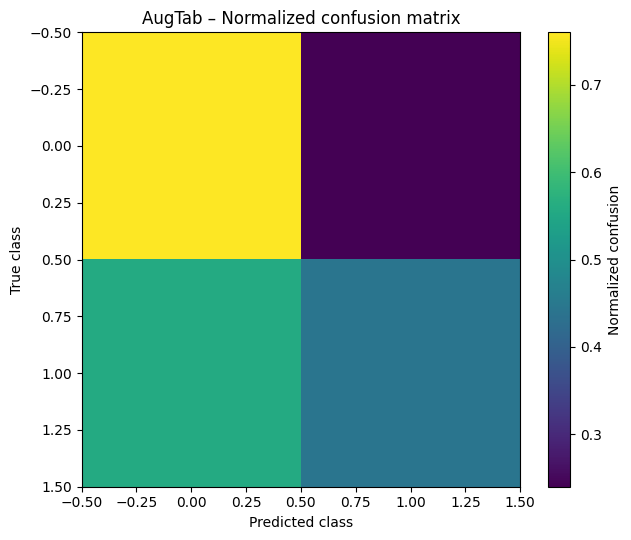


=== Top-10 most frequent confusions (true → predicted) ===
 1. true=1 → pred=0 | count=143
 2. true=0 → pred=1 | count=96
Top-1 accuracy: 63.57%
Top-2 accuracy: 100.00%


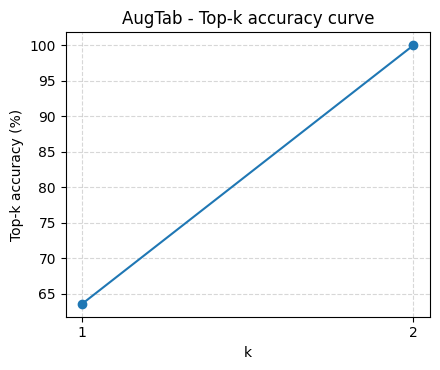


Mean margin (correct): 0.809
Mean margin (wrong)  : 0.811


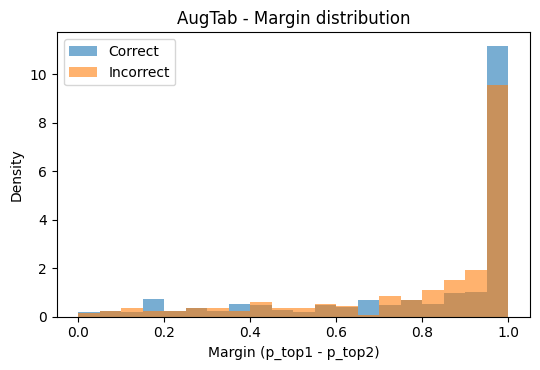


Detected tabular features: m = 9

=== Per-feature permutation importance (accuracy drop, % points) ===
Baseline accuracy: 63.57%
feat_0               | acc= 57.16% | drop=  6.40 pts
feat_1               | acc= 56.86% | drop=  6.71 pts
feat_2               | acc= 57.47% | drop=  6.10 pts
feat_3               | acc= 58.69% | drop=  4.88 pts
feat_4               | acc= 55.95% | drop=  7.62 pts
feat_5               | acc= 62.96% | drop=  0.61 pts
feat_6               | acc= 61.13% | drop=  2.44 pts
feat_7               | acc= 62.35% | drop=  1.22 pts
feat_8               | acc= 63.57% | drop=  0.00 pts

Top-15 most important features (by accuracy drop):
   idx  acc_drop    feat
4    4      7.62  feat_4
1    1      6.71  feat_1
0    0      6.40  feat_0
2    2      6.10  feat_2
3    3      4.88  feat_3
6    6      2.44  feat_6
7    7      1.22  feat_7
5    5      0.61  feat_5
8    8      0.00  feat_8


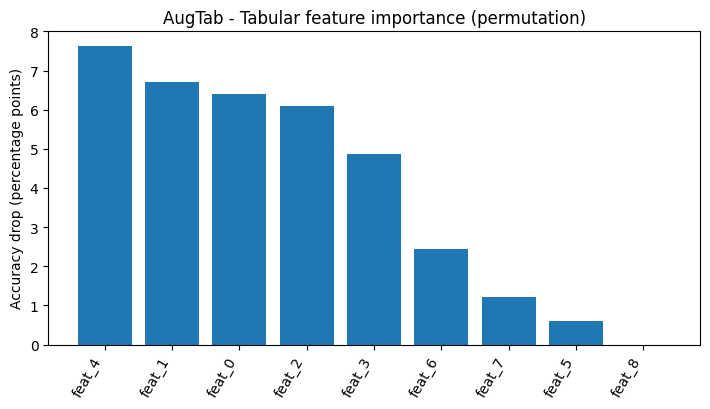


[Done] Extra diagnostics pack (AugTab) finished.
Saved figures:
  - augtab_confusion_matrix_norm.png
  - augtab_topk_accuracy.png
  - augtab_margin_hist.png
  - augtab_tab_feature_importance.png


In [11]:
# ============================================================
# Extra reliability & interpretability diagnostics for AugTab
#   1) Confusion matrix + normalized confusion
#   2) Top-k accuracy curve
#   3) Margin / confidence separation
#   4) Per-feature permutation importance (accuracy drop)
#
# Requires:
#   - best_model
#   - X_te
#   - y_te
#   - optionally best_params
#   - optionally X_train_scaled (for feature names)
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, top_k_accuracy_score
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})


# ------------------------------------------------------------
# 0. Build test DataLoader for AugTab
# ------------------------------------------------------------
device = best_model.device if hasattr(best_model, "device") else ("cuda" if torch.cuda.is_available() else "cpu")

if isinstance(X_te, pd.DataFrame):
    X_te_arr = X_te.values.astype(np.float32)
else:
    X_te_arr = np.asarray(X_te, dtype=np.float32)

if isinstance(y_te, pd.Series):
    y_te_arr = y_te.to_numpy()
else:
    y_te_arr = np.asarray(y_te)

y_te_arr = y_te_arr.astype(int)

X_te_t = torch.tensor(X_te_arr, dtype=torch.float32)
y_te_t = torch.tensor(y_te_arr, dtype=torch.long)

batch_size = best_params.get("batch_size", 64) if "best_params" in globals() else 64
te_ds = TensorDataset(X_te_t, y_te_t)
te_loader = DataLoader(te_ds, batch_size=batch_size, shuffle=False)

print(f"[INFO] Built AugTab test DataLoader: {len(te_loader)} batches, batch_size={batch_size}")
print(f"[INFO] X_te shape: {X_te_arr.shape}, y_te shape: {y_te_arr.shape}")
print(f"[INFO] Diagnostics using AugTab on device={device}")


# ------------------------------------------------------------
# 1. Helper: AugTab prediction function
#    Returns:
#      probs: (N, C)
#      preds: (N,)
#      y:     (N,)
# ------------------------------------------------------------
@torch.no_grad()
def augtab_predict_proba_numpy(wrapper_model, X_np):
    """
    Returns class probabilities as numpy array.
    Handles binary and multiclass output.
    """
    out = wrapper_model.predict_proba(X_np)

    if isinstance(out, torch.Tensor):
        probs = out.detach().cpu().numpy()
    else:
        probs = np.asarray(out)

    # Binary case: shape (N,) or (N,1) -> convert to (N,2)
    if probs.ndim == 1:
        probs_pos = probs.reshape(-1, 1)
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)
    elif probs.ndim == 2 and probs.shape[1] == 1:
        probs_pos = probs
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)

    # Normalize for safety
    row_sums = probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    probs = probs / row_sums

    return probs


@torch.no_grad()
def predict_loader_augtab(loader, perturb=None):
    """
    Runs AugTab on a DataLoader of (xb, yb).

    Returns:
        probs: (N, C)
        preds: (N,)
        y:     (N,)
    """
    probs_all, preds_all, y_all = [], [], []

    for xb, yb in loader:
        xb_np = xb.numpy().astype(np.float32)

        if perturb is not None:
            xb_np = perturb(xb_np)

        probs = augtab_predict_proba_numpy(best_model, xb_np)
        preds = probs.argmax(axis=1)

        probs_all.append(probs)
        preds_all.append(preds)
        y_all.append(yb.numpy())

    probs = np.concatenate(probs_all, axis=0)
    preds = np.concatenate(preds_all, axis=0)
    y     = np.concatenate(y_all, axis=0)

    return probs, preds, y


# ------------------------------------------------------------
# 2. Run base forward pass
# ------------------------------------------------------------
probs, preds, y = predict_loader_augtab(te_loader, perturb=None)

num_classes = probs.shape[1]
base_acc = accuracy_score(y, preds) * 100.0
print(f"Base accuracy on test loader: {base_acc:.2f}% (N={len(y)})")
print(f"Detected num_classes from probs: {num_classes}")


# ------------------------------------------------------------
# 3. Confusion matrix + normalized confusion
# ------------------------------------------------------------
cm = confusion_matrix(y, preds, labels=np.arange(num_classes))

with np.errstate(divide="ignore", invalid="ignore"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm[np.isnan(cm_norm)] = 0.0

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm_norm, interpolation="nearest", aspect="auto")
plt.colorbar(label="Normalized confusion")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("AugTab – Normalized confusion matrix")
plt.tight_layout()
plt.savefig("augtab_confusion_matrix_norm.png", dpi=600, bbox_inches="tight")
plt.show()

conf_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i == j:
            continue
        if cm[i, j] > 0:
            conf_pairs.append((cm[i, j], i, j))
conf_pairs.sort(reverse=True)

print("\n=== Top-10 most frequent confusions (true → predicted) ===")
for k in range(min(10, len(conf_pairs))):
    c, i, j = conf_pairs[k]
    print(f"{k+1:2d}. true={i} → pred={j} | count={c}")


# ------------------------------------------------------------
# 4. Top-k accuracy curve
# ------------------------------------------------------------
topk_accs = []

if num_classes == 2:
    # In binary classification:
    # Top-1 = standard accuracy
    # Top-2 = always 100% if both classes are included
    ks = [1, 2]
    for k in ks:
        if k == 1:
            acc_k = base_acc
        else:
            acc_k = 100.0
        topk_accs.append(acc_k)
        print(f"Top-{k} accuracy: {acc_k:.2f}%")
else:
    ks = [k for k in [1, 2, 3, 5] if k <= num_classes]
    for k in ks:
        acc_k = top_k_accuracy_score(
            y,
            probs,
            k=k,
            labels=np.arange(num_classes)
        ) * 100.0
        topk_accs.append(acc_k)
        print(f"Top-{k} accuracy: {acc_k:.2f}%")

plt.figure(figsize=(4.5, 3.8))
plt.plot(ks, topk_accs, "-o")
plt.xticks(ks)
plt.xlabel("k")
plt.ylabel("Top-k accuracy (%)")
plt.title("AugTab - Top-k accuracy curve")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("augtab_topk_accuracy.png", dpi=600, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 5. Margin / confidence separation
#    margin = p_top1 - p_top2
# ------------------------------------------------------------
sorted_probs = np.sort(probs, axis=1)[:, ::-1]
top1 = sorted_probs[:, 0]
top2 = sorted_probs[:, 1] if sorted_probs.shape[1] > 1 else np.zeros_like(top1)
margins = top1 - top2

correct = (preds == y)
margins_correct = margins[correct]
margins_wrong   = margins[~correct]

mean_margin_correct = margins_correct.mean() if len(margins_correct) > 0 else np.nan
mean_margin_wrong   = margins_wrong.mean() if len(margins_wrong) > 0 else np.nan

print(f"\nMean margin (correct): {mean_margin_correct:.3f}")
print(f"Mean margin (wrong)  : {mean_margin_wrong:.3f}")

plt.figure(figsize=(5.5, 3.8))
bins = np.linspace(0.0, 1.0, 21)

if len(margins_correct) > 0:
    plt.hist(margins_correct, bins=bins, alpha=0.6, label="Correct", density=True)
if len(margins_wrong) > 0:
    plt.hist(margins_wrong, bins=bins, alpha=0.6, label="Incorrect", density=True)

plt.xlabel("Margin (p_top1 - p_top2)")
plt.ylabel("Density")
plt.title("AugTab - Margin distribution")
plt.legend()
plt.tight_layout()
plt.savefig("augtab_margin_hist.png", dpi=600, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 6. Per-feature permutation importance (accuracy drop)
#    Shuffle one feature column across samples, measure acc drop
# ------------------------------------------------------------
xb0, yb0 = next(iter(te_loader))
m_features = xb0.shape[1]
print(f"\nDetected tabular features: m = {m_features}")

feature_names = None
if isinstance(X_te, pd.DataFrame):
    feature_names = list(X_te.columns)
elif "X_train_scaled" in globals():
    if isinstance(X_train_scaled, pd.DataFrame):
        if len(X_train_scaled.columns) == m_features:
            feature_names = list(X_train_scaled.columns)

if feature_names is None:
    feature_names = [f"feat_{i}" for i in range(m_features)]


def make_single_feature_shuffler(idx):
    """
    Returns perturb(xb_np) that shuffles one feature column across batch.
    xb_np: (B, m) numpy array
    """
    def _perturb(xb_np):
        xb_np = xb_np.copy()
        B = xb_np.shape[0]
        perm = np.random.permutation(B)
        xb_np[:, idx] = xb_np[perm, idx]
        return xb_np
    return _perturb


def eval_accuracy(loader, perturb=None):
    _, p, yy = predict_loader_augtab(loader, perturb=perturb)
    return accuracy_score(yy, p) * 100.0


print("\n=== Per-feature permutation importance (accuracy drop, % points) ===")
print(f"Baseline accuracy: {base_acc:.2f}%")

drops = []
for i in range(m_features):
    acc_i = eval_accuracy(te_loader, perturb=make_single_feature_shuffler(i))
    drop = base_acc - acc_i
    fname = feature_names[i] if i < len(feature_names) else f"feat_{i}"
    drops.append((i, drop, fname))
    print(f"{fname:20s} | acc={acc_i:6.2f}% | drop={drop:6.2f} pts")

df_imp = pd.DataFrame(drops, columns=["idx", "acc_drop", "feat"])
df_imp = df_imp.sort_values("acc_drop", ascending=False)

print("\nTop-15 most important features (by accuracy drop):")
print(df_imp.head(15).round(2))

K = min(20, len(df_imp))
top_df = df_imp.head(K)

plt.figure(figsize=(7.2, 4.2))
plt.bar(range(K), top_df["acc_drop"])
plt.xticks(range(K), top_df["feat"], rotation=60, ha="right")
plt.ylabel("Accuracy drop (percentage points)")
plt.title("AugTab - Tabular feature importance (permutation)")
plt.tight_layout()
plt.savefig("augtab_tab_feature_importance.png", dpi=600, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------
print("\n[Done] Extra diagnostics pack (AugTab) finished.")
print("Saved figures:")
print("  - augtab_confusion_matrix_norm.png")
print("  - augtab_topk_accuracy.png")
print("  - augtab_margin_hist.png")
print("  - augtab_tab_feature_importance.png")

# Theory-Inspired Representation Diagnostics

[INFO] Theory-ish diagnostics using AugTab on device=cuda
[INFO] Using existing te_loader
[Info] N=656 samples, representation dim=384
[Info] Base top-1 accuracy: 63.57%
[Info] Num classes from logits/probs: 2

[Geom] Effective dimension (participation ratio): 37.4


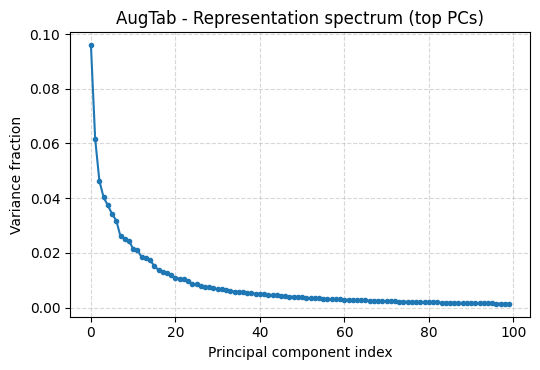

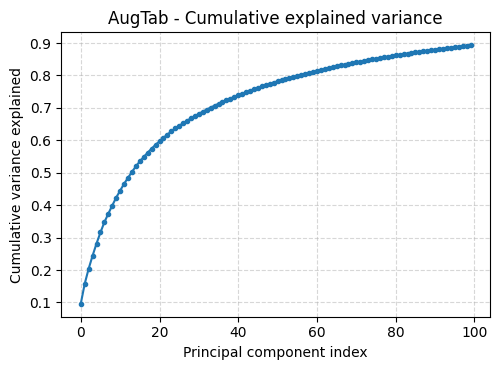


[Geom] Components needed for target variance:
   target_var  k_components
0        0.50            14
1        0.80            57
2        0.90           106
3        0.95           160
4        0.99           271
[kNN] Leave-one-out kNN accuracy (k=1): 52.74%
[kNN] Leave-one-out kNN accuracy (k=3): 56.10%
[kNN] Leave-one-out kNN accuracy (k=5): 56.25%
[kNN] Leave-one-out kNN accuracy (k=10): 60.21%
[kNN] Leave-one-out kNN accuracy (k=20): 62.80%


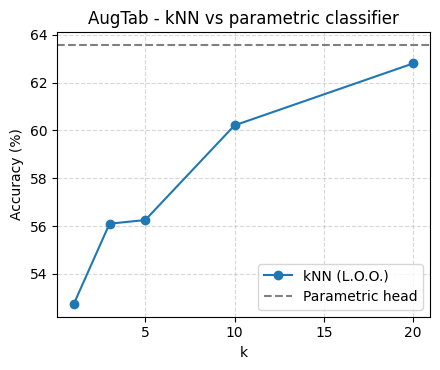


[Margin] Mean normalized margin (correct):   1.4142
[Margin] Mean normalized margin (incorrect): -1.4142


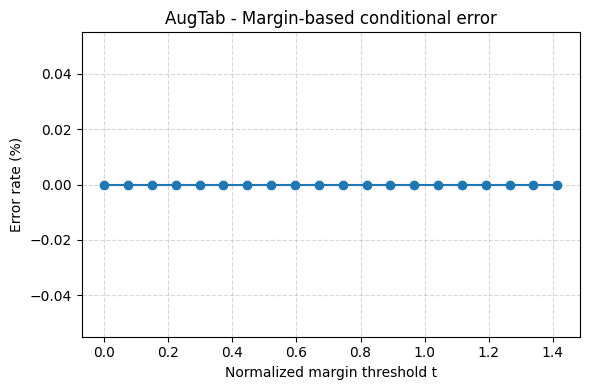

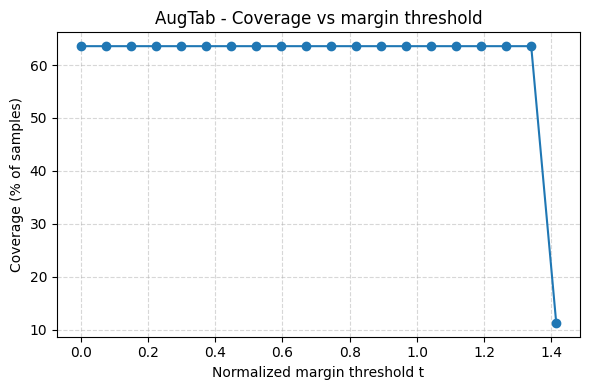


[Done] Theory-ish diagnostics (AugTab) complete.
Saved figures:
  - augtab_embedding_spectrum.png
  - augtab_embedding_cumulative_variance.png
  - augtab_knn_vs_head.png
  - augtab_margin_conditional_error.png
  - augtab_margin_coverage.png


In [12]:
# ============= Theory-ish diagnostics: geometry, kNN, margins (AugTab) =============
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# -------------------------------------------------------------------
# 0. Hook AugTab model + test loader
# -------------------------------------------------------------------
model = best_model
device = model.device if hasattr(model, "device") else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Theory-ish diagnostics using AugTab on device={device}")

# Build te_loader if not already defined
if "te_loader" not in globals():
    print("[INFO] te_loader not found in globals; rebuilding from X_te / y_te ...")

    if isinstance(X_te, pd.DataFrame):
        X_te_arr = X_te.values.astype(np.float32)
    else:
        X_te_arr = np.asarray(X_te, dtype=np.float32)

    if isinstance(y_te, pd.Series):
        y_te_arr = y_te.to_numpy()
    else:
        y_te_arr = np.asarray(y_te)

    y_te_arr = y_te_arr.astype(int)

    X_te_t = torch.tensor(X_te_arr, dtype=torch.float32)
    y_te_t = torch.tensor(y_te_arr, dtype=torch.long)

    batch_size = best_params.get("batch_size", 64) if "best_params" in globals() else 64
    te_ds = TensorDataset(X_te_t, y_te_t)
    te_loader = DataLoader(te_ds, batch_size=batch_size, shuffle=False)

    print(f"[INFO] Built AugTab test DataLoader: {len(te_loader)} batches, batch_size={batch_size}")
else:
    print("[INFO] Using existing te_loader")


# -------------------------------------------------------------------
# 1. Helpers for AugTab: probs, logits, reps
# -------------------------------------------------------------------
def find_final_linear_head(net):
    """
    Choose the last nn.Linear layer as final prediction head.
    """
    linears = []
    for name, mod in net.named_modules():
        if isinstance(mod, nn.Linear):
            linears.append((name, mod))
    if len(linears) == 0:
        raise RuntimeError("No nn.Linear layer found in AugTab model.")
    return linears[-1][0], linears[-1][1]


@torch.no_grad()
def augtab_forward_with_reps(wrapper_model, X_np):
    """
    Returns:
      logits: (N, C) or (N, 1)
      probs : (N, C)
      preds : (N,)
      reps  : (N, d_rep)

    reps are taken as the input to the final linear head.
    """
    net = wrapper_model.model
    net.eval()

    Xt = torch.tensor(np.asarray(X_np, dtype=np.float32), dtype=torch.float32, device=wrapper_model.device)

    head_name, head_mod = find_final_linear_head(net)
    captured = {"reps": None}

    def hook_fn(module, inputs, output):
        z = inputs[0]
        captured["reps"] = z.detach().cpu()

    h = head_mod.register_forward_hook(hook_fn)
    out = net(Xt)
    h.remove()

    if isinstance(out, tuple):
        out = out[0]

    logits_t = out.detach().cpu()

    # convert logits/output to probabilities
    if logits_t.ndim == 1:
        logits_t = logits_t[:, None]

    logits_np = logits_t.numpy()

    # Binary case: output shape (N,1) or sometimes sigmoid-like
    if logits_np.shape[1] == 1:
        z = logits_np[:, 0]
        probs_pos = 1.0 / (1.0 + np.exp(-z))
        probs = np.stack([1.0 - probs_pos, probs_pos], axis=1)
        preds = (probs_pos >= 0.5).astype(int)

        # also expand logits to 2 columns for margin-style analysis
        logits_2c = np.stack([-z, z], axis=1)
        logits_np = logits_2c
    else:
        z = logits_np - logits_np.max(axis=1, keepdims=True)
        exp_z = np.exp(z)
        probs = exp_z / (exp_z.sum(axis=1, keepdims=True) + 1e-12)
        preds = probs.argmax(axis=1)

    reps = captured["reps"]
    if reps is None:
        raise RuntimeError("Failed to capture AugTab sample representations.")
    reps = reps.numpy()
    if reps.ndim == 1:
        reps = reps[:, None]

    return logits_np, probs, preds, reps


@torch.no_grad()
def predict_loader_augtab(loader, perturb=None):
    """
    Runs AugTab on a DataLoader of (xb, yb).

    Returns:
      logits: (N, C)
      probs : (N, C)
      preds : (N,)
      y     : (N,)
      embs  : (N, d_rep)
    """
    logits_all, probs_all, preds_all, y_all, embs_all = [], [], [], [], []

    for xb, yb in loader:
        xb_np = xb.numpy().astype(np.float32)

        if perturb is not None:
            xb_np = perturb(xb_np)

        logits, probs, preds, reps = augtab_forward_with_reps(model, xb_np)

        logits_all.append(logits)
        probs_all.append(probs)
        preds_all.append(preds)
        y_all.append(yb.numpy())
        embs_all.append(reps)

    logits = np.concatenate(logits_all, axis=0)
    probs  = np.concatenate(probs_all, axis=0)
    preds  = np.concatenate(preds_all, axis=0)
    y      = np.concatenate(y_all, axis=0)
    embs   = np.concatenate(embs_all, axis=0)

    return logits, probs, preds, y, embs


# ---------- 2. Get cached predictions & embeddings ----------
logits, probs, preds, y, embs = predict_loader_augtab(te_loader, perturb=None)

y     = np.asarray(y).astype(int)
preds = np.asarray(preds).astype(int)
N, D  = embs.shape

print(f"[Info] N={N} samples, representation dim={D}")
base_acc = accuracy_score(y, preds) * 100.0
print(f"[Info] Base top-1 accuracy: {base_acc:.2f}%")
print(f"[Info] Num classes from logits/probs: {probs.shape[1]}")


# ---------- 3. Representation spectrum & effective dimension ----------
embs_c = embs - embs.mean(axis=0, keepdims=True)

# Covariance in representation space
if D == 1:
    cov = np.array([[np.var(embs_c[:, 0])]])
else:
    cov = np.cov(embs_c, rowvar=False)

evals, _ = np.linalg.eigh(cov)
evals = np.sort(np.maximum(evals, 0))[::-1]

total_var = evals.sum() + 1e-12
explained = evals / total_var
cum_expl  = np.cumsum(explained)

eff_dim = (total_var ** 2) / (np.sum(evals ** 2) + 1e-12)
print(f"\n[Geom] Effective dimension (participation ratio): {eff_dim:.1f}")

plt.figure(figsize=(5.5, 3.8))
plt.plot(explained[:min(100, len(explained))], "-o", markersize=3)
plt.xlabel("Principal component index")
plt.ylabel("Variance fraction")
plt.title("AugTab - Representation spectrum (top PCs)")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("augtab_embedding_spectrum.png", dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(5.1, 3.8))
plt.plot(cum_expl[:min(100, len(cum_expl))], "-o", markersize=3)
plt.xlabel("Principal component index")
plt.ylabel("Cumulative variance explained")
plt.title("AugTab - Cumulative explained variance")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("augtab_embedding_cumulative_variance.png", dpi=600, bbox_inches="tight")
plt.show()

targets = [0.5, 0.8, 0.9, 0.95, 0.99]
rows = []
for t in targets:
    k = int(np.searchsorted(cum_expl, t) + 1)
    rows.append({"target_var": t, "k_components": k})
df_var = pd.DataFrame(rows)

print("\n[Geom] Components needed for target variance:")
print(df_var)


# ---------- 4. kNN classifier vs parametric head ----------
ks = [1, 3, 5, 10, 20]
ks = [k for k in ks if k < N]  # must be < N for leave-one-out style
knn_accs = []

nbrs = KNeighborsClassifier(n_neighbors=min(max(ks) + 1, N), metric="euclidean")
nbrs.fit(embs, y)
dist, neigh_idx = nbrs.kneighbors(embs, return_distance=True)

for k in ks:
    neigh_k = neigh_idx[:, 1:k+1]   # drop self
    y_pred_knn = []

    for i in range(N):
        neigh_labels = y[neigh_k[i]]
        vals, counts = np.unique(neigh_labels, return_counts=True)
        y_pred_knn.append(vals[counts.argmax()])

    y_pred_knn = np.array(y_pred_knn)
    acc_k = accuracy_score(y, y_pred_knn) * 100.0
    knn_accs.append(acc_k)
    print(f"[kNN] Leave-one-out kNN accuracy (k={k}): {acc_k:.2f}%")

plt.figure(figsize=(4.5, 3.8))
plt.plot(ks, knn_accs, "-o", label="kNN (L.O.O.)")
plt.axhline(base_acc, color="gray", linestyle="--", label="Parametric head")
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("AugTab - kNN vs parametric classifier")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("augtab_knn_vs_head.png", dpi=600, bbox_inches="tight")
plt.show()


# ---------- 5. Margin-based view ----------
# Margin: f_y(x) - max_{j≠y} f_j(x), using logits
logits_np = np.asarray(logits)
num_classes = logits_np.shape[1]

true_logits = logits_np[np.arange(N), y]

tmp = logits_np.copy()
tmp[np.arange(N), y] = -1e9
second_best = tmp.max(axis=1)

margins = true_logits - second_best

logit_norm   = np.linalg.norm(logits_np, axis=1) + 1e-12
norm_margins = margins / logit_norm

correct = (preds == y)
m_corr  = norm_margins[correct]
m_wrong = norm_margins[~correct]

mean_corr = m_corr.mean() if len(m_corr) > 0 else np.nan
mean_wrong = m_wrong.mean() if len(m_wrong) > 0 else np.nan

print(f"\n[Margin] Mean normalized margin (correct):   {mean_corr:.4f}")
print(f"[Margin] Mean normalized margin (incorrect): {mean_wrong:.4f}")

ths = np.linspace(0.0, np.percentile(norm_margins, 99), 20)
err_cond = []
cov_cond = []

for t in ths:
    idx = np.where(norm_margins >= t)[0]
    if len(idx) == 0:
        err_cond.append(np.nan)
        cov_cond.append(0.0)
    else:
        err_cond.append(1.0 - accuracy_score(y[idx], preds[idx]))
        cov_cond.append(len(idx) / N)

err_cond = np.array(err_cond) * 100.0
cov_cond = np.array(cov_cond) * 100.0

plt.figure(figsize=(6.0, 4.0))
plt.plot(ths, err_cond, "-o")
plt.xlabel("Normalized margin threshold t")
plt.ylabel("Error rate (%)")
plt.title("AugTab - Margin-based conditional error")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("augtab_margin_conditional_error.png", dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6.0, 4.0))
plt.plot(ths, cov_cond, "-o")
plt.xlabel("Normalized margin threshold t")
plt.ylabel("Coverage (% of samples)")
plt.title("AugTab - Coverage vs margin threshold")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("augtab_margin_coverage.png", dpi=600, bbox_inches="tight")
plt.show()


print("\n[Done] Theory-ish diagnostics (AugTab) complete.")
print("Saved figures:")
print("  - augtab_embedding_spectrum.png")
print("  - augtab_embedding_cumulative_variance.png")
print("  - augtab_knn_vs_head.png")
print("  - augtab_margin_conditional_error.png")
print("  - augtab_margin_coverage.png")

# OOD and Local Sensitivity Diagnostics

[INFO] OOD + sensitivity diagnostics with AugTab on device=cuda
[Data] Test shape: N=656, M=9 features
[ID] N=656, accuracy=63.57%
[ID] mean(max_conf)=0.905, mean(entropy)=0.216
[Noise] mean(max_conf)=0.908, mean(entropy)=0.213
[Perm ] mean(max_conf)=0.913, mean(entropy)=0.205
[Const] mean(max_conf)=0.992, mean(entropy)=0.047


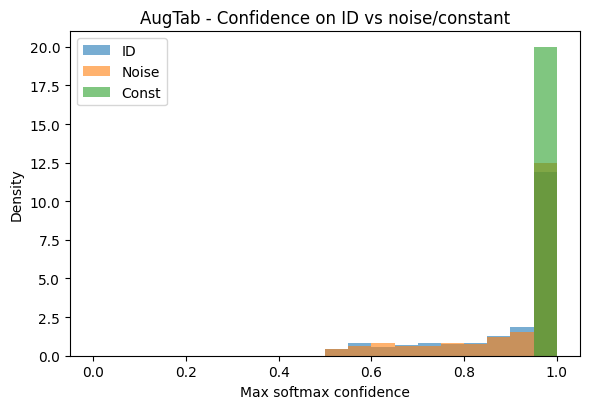

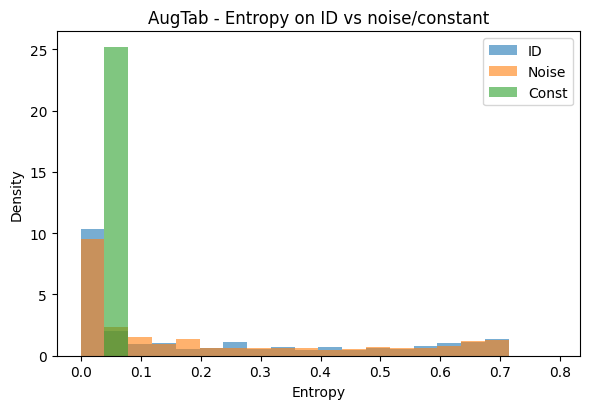


[Local sensitivity] tab eps=0.10, mean ratio=4.748, median=4.240


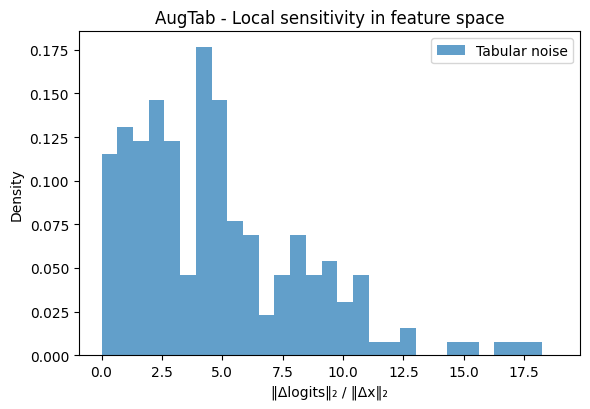


[Done] OOD + sensitivity diagnostics (AugTab) complete.
Saved figures:
  - augtab_conf_id_vs_noise_const.png
  - augtab_entropy_id_vs_noise_const.png
  - augtab_local_sensitivity_tab.png


In [14]:
# ===================== OOD + sensitivity diagnostics (AugTab, tabular) =====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ---- Use AugTab best model + tabular test split ----
model = best_model
device = model.device if hasattr(model, "device") else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] OOD + sensitivity diagnostics with AugTab on device={device}")

# ---- Build test matrix (ID data) ----
if isinstance(X_te, pd.DataFrame):
    X_te_arr = X_te.values.astype(np.float32)
else:
    X_te_arr = np.asarray(X_te, dtype=np.float32)

if isinstance(y_te, pd.Series):
    y_te_arr = y_te.to_numpy()
else:
    y_te_arr = np.asarray(y_te)

y_te_arr = y_te_arr.astype(int)

N, M = X_te_arr.shape
print(f"[Data] Test shape: N={N}, M={M} features")

# ---- Small DataLoader for reuse ----
batch_size = best_params.get("batch_size", 64) if "best_params" in globals() else 64
X_te_t = torch.tensor(X_te_arr, dtype=torch.float32)
y_te_t = torch.tensor(y_te_arr, dtype=torch.long)
test_ds = TensorDataset(X_te_t, y_te_t)
test_loader_a = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
@torch.no_grad()
def augtab_predict_proba_numpy(wrapper_model, X_np):
    """
    Returns class probabilities as numpy array.
    Handles binary and multiclass output.
    """
    out = wrapper_model.predict_proba(X_np)

    if isinstance(out, torch.Tensor):
        probs = out.detach().cpu().numpy()
    else:
        probs = np.asarray(out)

    # Binary case: shape (N,) or (N,1) -> convert to (N,2)
    if probs.ndim == 1:
        probs_pos = probs.reshape(-1, 1)
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)
    elif probs.ndim == 2 and probs.shape[1] == 1:
        probs_pos = probs
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)

    row_sums = probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    probs = probs / row_sums

    return probs


@torch.no_grad()
def augtab_logits_numpy(wrapper_model, X_np, batch_size=256):
    """
    Returns raw logits from wrapper_model.model(...) as numpy array.
    Output:
      binary   -> converted to shape (N,2) as [-z, z]
      multicls -> shape (N,C)
    """
    net = wrapper_model.model
    net.eval()

    X_np = np.asarray(X_np, dtype=np.float32)
    outs = []

    for i in range(0, len(X_np), batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=wrapper_model.device)
        out = net(xb)

        if isinstance(out, tuple):
            out = out[0]

        out = out.detach().cpu()

        if out.ndim == 1:
            out = out[:, None]

        outs.append(out)

    logits = torch.cat(outs, dim=0).numpy()

    # Binary case: expand (N,1) to (N,2)
    if logits.ndim == 2 and logits.shape[1] == 1:
        z = logits[:, 0]
        logits = np.stack([-z, z], axis=1)

    return logits


@torch.no_grad()
def predict_loader_augtab(loader):
    """
    Runs AugTab on a DataLoader of (xb, yb).

    Returns:
        logits: (N, C)
        probs:  (N, C)
        preds:  (N,)
        y:      (N,)
    """
    logits_all, probs_all, preds_all, y_all = [], [], [], []

    for xb, yb in loader:
        xb_np = xb.numpy().astype(np.float32)

        logits = augtab_logits_numpy(model, xb_np, batch_size=len(xb_np))
        probs  = augtab_predict_proba_numpy(model, xb_np)
        preds  = probs.argmax(axis=1)

        logits_all.append(logits)
        probs_all.append(probs)
        preds_all.append(preds)
        y_all.append(yb.numpy())

    logits = np.concatenate(logits_all, axis=0)
    probs  = np.concatenate(probs_all, axis=0)
    preds  = np.concatenate(preds_all, axis=0)
    y      = np.concatenate(y_all, axis=0)

    return logits, probs, preds, y


@torch.no_grad()
def run_on_array_augtab(X_arr, batch_size=256):
    """
    X_arr: (N, M) float32
    Returns:
        logits, probs, max_conf, entropy
    """
    logits  = augtab_logits_numpy(model, X_arr, batch_size=batch_size)
    probs   = augtab_predict_proba_numpy(model, X_arr)
    maxconf = probs.max(axis=1)
    entropy = -(probs * np.log(probs + 1e-12)).sum(axis=1)
    return logits, probs, maxconf, entropy


# -------------------------------------------------------------------
# 0. ID baseline stats
# -------------------------------------------------------------------
logits_id, probs_id, preds_id, y_id = predict_loader_augtab(test_loader_a)
probs_id = np.asarray(probs_id)
y_id     = np.asarray(y_id)
preds_id = np.asarray(preds_id)

maxconf_id = probs_id.max(axis=1)
entropy_id = -(probs_id * np.log(probs_id + 1e-12)).sum(axis=1)

print(f"[ID] N={len(y_id)}, accuracy={(preds_id == y_id).mean() * 100:.2f}%")
print(f"[ID] mean(max_conf)={maxconf_id.mean():.3f}, mean(entropy)={entropy_id.mean():.3f}")


# -------------------------------------------------------------------
# 1. Build OOD-ish tabular inputs
# -------------------------------------------------------------------
np.random.seed(0)

# 1a) Gaussian noise features
X_noise = np.random.normal(loc=0.0, scale=1.0, size=X_te_arr.shape).astype(np.float32)

# 1b) Column-shuffled features (break joint structure)
X_perm = X_te_arr.copy()
rng = np.random.default_rng(1)
for j in range(M):
    perm = rng.permutation(N)
    X_perm[:, j] = X_perm[perm, j]

# 1c) Constant "blank" features: dataset-wise mean per column
X_const = np.tile(X_te_arr.mean(axis=0, keepdims=True), (N, 1)).astype(np.float32)


# -------------------------------------------------------------------
# 1'. Run AugTab on OOD sets
# -------------------------------------------------------------------
_, probs_noise, maxconf_noise, entropy_noise = run_on_array_augtab(X_noise, batch_size=batch_size)
_, probs_perm,  maxconf_perm,  entropy_perm  = run_on_array_augtab(X_perm,  batch_size=batch_size)
_, probs_const, maxconf_const, entropy_const = run_on_array_augtab(X_const, batch_size=batch_size)

print(f"[Noise] mean(max_conf)={maxconf_noise.mean():.3f}, mean(entropy)={entropy_noise.mean():.3f}")
print(f"[Perm ] mean(max_conf)={maxconf_perm.mean():.3f}, mean(entropy)={entropy_perm.mean():.3f}")
print(f"[Const] mean(max_conf)={maxconf_const.mean():.3f}, mean(entropy)={entropy_const.mean():.3f}")


# -------------------------------------------------------------------
# 2. Confidence & entropy histograms
# -------------------------------------------------------------------
bins_conf = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(6.0, 4.2))
plt.hist(maxconf_id,    bins=bins_conf, alpha=0.6, label="ID",    density=True)
plt.hist(maxconf_noise, bins=bins_conf, alpha=0.6, label="Noise", density=True)
plt.hist(maxconf_const, bins=bins_conf, alpha=0.6, label="Const", density=True)
plt.xlabel("Max softmax confidence")
plt.ylabel("Density")
plt.title("AugTab - Confidence on ID vs noise/constant")
plt.legend()
plt.tight_layout()
plt.savefig("augtab_conf_id_vs_noise_const.png", dpi=600, bbox_inches="tight")
plt.show()

bins_ent = np.linspace(0.0, np.log(probs_id.shape[1]) + 0.1, 21)

plt.figure(figsize=(6.0, 4.2))
plt.hist(entropy_id,    bins=bins_ent, alpha=0.6, label="ID",    density=True)
plt.hist(entropy_noise, bins=bins_ent, alpha=0.6, label="Noise", density=True)
plt.hist(entropy_const, bins=bins_ent, alpha=0.6, label="Const", density=True)
plt.xlabel("Entropy")
plt.ylabel("Density")
plt.title("AugTab - Entropy on ID vs noise/constant")
plt.legend()
plt.tight_layout()
plt.savefig("augtab_entropy_id_vs_noise_const.png", dpi=600, bbox_inches="tight")
plt.show()


# -------------------------------------------------------------------
# 3. Local sensitivity (Lipschitz-ish in feature space)
# -------------------------------------------------------------------
@torch.no_grad()
def local_sensitivity_augtab(X_arr, eps=0.10, n_samples=200, batch_size=32):
    """
    Approximate local Lipschitz constant:
        ratio = ||Δlogits||_2 / ||Δx||_2
    where Δx is small random L2-normalized noise in feature space.
    """
    net = model.model
    net.eval()

    X_arr = np.asarray(X_arr, dtype=np.float32)
    X_arr_t = torch.tensor(X_arr, dtype=torch.float32)

    N_local = X_arr_t.shape[0]
    idx = np.random.choice(N_local, size=min(n_samples, N_local), replace=False)

    ratios = []

    for start in range(0, len(idx), batch_size):
        batch_idx = idx[start:start+batch_size]
        if len(batch_idx) == 0:
            break

        xb = X_arr_t[batch_idx].to(device)   # (B, M)

        # Base logits
        logits_base = net(xb)
        if isinstance(logits_base, tuple):
            logits_base = logits_base[0]
        if logits_base.ndim == 1:
            logits_base = logits_base[:, None]
        if logits_base.shape[1] == 1:
            z = logits_base[:, 0]
            logits_base = torch.stack([-z, z], dim=1)

        # Random L2-normalized noise in feature space
        noise = torch.randn_like(xb)
        noise_flat = noise.view(noise.size(0), -1)
        norm = torch.norm(noise_flat, dim=1, keepdim=True) + 1e-12
        noise_unit = noise / norm
        noise = noise_unit * eps

        xb_pert = xb + noise

        # Perturbed logits
        logits_pert = net(xb_pert)
        if isinstance(logits_pert, tuple):
            logits_pert = logits_pert[0]
        if logits_pert.ndim == 1:
            logits_pert = logits_pert[:, None]
        if logits_pert.shape[1] == 1:
            z = logits_pert[:, 0]
            logits_pert = torch.stack([-z, z], dim=1)

        diff = logits_pert - logits_base
        diff_norm = diff.view(diff.size(0), -1).norm(dim=1)

        # actual ||Δx||
        inp_norm = noise.view(noise.size(0), -1).norm(dim=1)

        ratios.extend((diff_norm / (inp_norm + 1e-12)).detach().cpu().numpy())

    return np.array(ratios)


sens_tab = local_sensitivity_augtab(X_te_arr, eps=0.10, n_samples=200, batch_size=batch_size)

print(f"\n[Local sensitivity] tab eps=0.10, mean ratio={sens_tab.mean():.3f}, median={np.median(sens_tab):.3f}")

plt.figure(figsize=(6.0, 4.2))
bins_s = np.linspace(0.0, sens_tab.max() * 1.05 if len(sens_tab) > 0 else 1.0, 30)
plt.hist(sens_tab, bins=bins_s, alpha=0.7, label="Tabular noise", density=True)
plt.xlabel("‖Δlogits‖₂ / ‖Δx‖₂")
plt.ylabel("Density")
plt.title("AugTab - Local sensitivity in feature space")
plt.legend()
plt.tight_layout()
plt.savefig("augtab_local_sensitivity_tab.png", dpi=600, bbox_inches="tight")
plt.show()


print("\n[Done] OOD + sensitivity diagnostics (AugTab) complete.")
print("Saved figures:")
print("  - augtab_conf_id_vs_noise_const.png")
print("  - augtab_entropy_id_vs_noise_const.png")
print("  - augtab_local_sensitivity_tab.png")

# Deployment-Oriented Triage Diagnostics

[INFO] Deployment-style diagnostics with AugTab on device=cuda
[Data] Test shape: N=656, M=9
[Info] N=656, num_classes=2
[Info] Base accuracy: 63.57%

[Triage] Using class 0 as positive vs others.
[Triage] Binary AUC (class 0 vs rest) = 0.610
[Triage] Chosen threshold th* = 0.0099 with sensitivity=0.950, specificity=0.156

[Triage] Confusion matrix at th* (rows=true, cols=pred):
          pred=0        pred=1
true=0         40         216
true=1         20         380

[Triage] Acc=64.02%, Prec=63.76%, Recall=95.00%


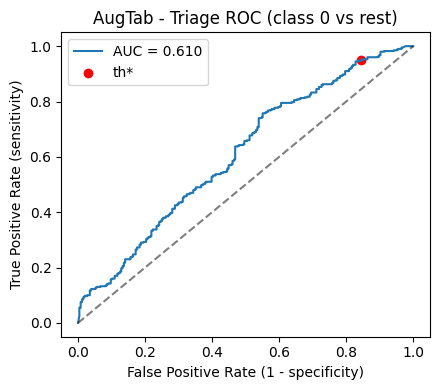


[Fairness] No `group_dict` found in globals; skipping fairness analysis.

[Reliability] Latency stats over up to 20 batches (AugTab):
  mean = 0.89 ms/batch
  p50  = 0.80 ms/batch
  p90  = 1.02 ms/batch
  p99  = 1.07 ms/batch

[Done] Deployment-style diagnostics (triage + fairness + latency, AugTab) complete.
If ROC ran, saved: augtab_triage_roc.png


In [15]:
# ============== Deployment-style diagnostics: triage & fairness & latency (AugTab) ==============
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import time

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    accuracy_score, precision_score, recall_score
)

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ----------------- 0) Hook AugTab model + test split -----------------
model = best_model
device = torch.device(model.device if hasattr(model, "device") else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"[INFO] Deployment-style diagnostics with AugTab on device={device}")

# Build test arrays
if isinstance(X_te, pd.DataFrame):
    X_te_arr = X_te.values.astype(np.float32)
else:
    X_te_arr = np.asarray(X_te, dtype=np.float32)

if isinstance(y_te, pd.Series):
    y_te_arr = y_te.to_numpy()
else:
    y_te_arr = np.asarray(y_te)

y_te_arr = y_te_arr.astype(int)

N, M = X_te_arr.shape
print(f"[Data] Test shape: N={N}, M={M}")

batch_size = best_params.get("batch_size", 64) if "best_params" in globals() else 64
X_te_t = torch.tensor(X_te_arr, dtype=torch.float32)
y_te_t = torch.tensor(y_te_arr, dtype=torch.long)
test_ds = TensorDataset(X_te_t, y_te_t)
test_loader_a = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


# ----------------- 1) Helpers for AugTab -----------------
@torch.no_grad()
def augtab_predict_proba_numpy(wrapper_model, X_np):
    """
    Returns class probabilities as numpy array.
    Handles binary and multiclass output.
    """
    out = wrapper_model.predict_proba(X_np)

    if isinstance(out, torch.Tensor):
        probs = out.detach().cpu().numpy()
    else:
        probs = np.asarray(out)

    # Binary case: shape (N,) or (N,1) -> convert to (N,2)
    if probs.ndim == 1:
        probs_pos = probs.reshape(-1, 1)
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)
    elif probs.ndim == 2 and probs.shape[1] == 1:
        probs_pos = probs
        probs = np.concatenate([1.0 - probs_pos, probs_pos], axis=1)

    # Normalize for safety
    row_sums = probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    probs = probs / row_sums

    return probs


@torch.no_grad()
def augtab_logits_numpy(wrapper_model, X_np, batch_size=256):
    """
    Returns raw logits from wrapper_model.model(...).
    Output:
      binary   -> converted to shape (N,2) as [-z, z]
      multicls -> shape (N,C)
    """
    net = wrapper_model.model
    net.eval()

    X_np = np.asarray(X_np, dtype=np.float32)
    outs = []

    for i in range(0, len(X_np), batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=wrapper_model.device)
        out = net(xb)

        if isinstance(out, tuple):
            out = out[0]

        out = out.detach().cpu()

        if out.ndim == 1:
            out = out[:, None]

        outs.append(out)

    logits = torch.cat(outs, dim=0).numpy()

    # Binary case: expand (N,1) to (N,2)
    if logits.ndim == 2 and logits.shape[1] == 1:
        z = logits[:, 0]
        logits = np.stack([-z, z], axis=1)

    return logits


@torch.no_grad()
def predict_loader_augtab(loader):
    """
    Runs AugTab on a DataLoader of (xb, yb).

    Returns:
        logits: (N, C)
        probs:  (N, C)
        preds:  (N,)
        y:      (N,)
    """
    logits_all, probs_all, preds_all, y_all = [], [], [], []

    for xb, yb in loader:
        xb_np = xb.numpy().astype(np.float32)

        logits = augtab_logits_numpy(model, xb_np, batch_size=len(xb_np))
        probs  = augtab_predict_proba_numpy(model, xb_np)
        preds  = probs.argmax(axis=1)

        logits_all.append(logits)
        probs_all.append(probs)
        preds_all.append(preds)
        y_all.append(yb.numpy())

    logits = np.concatenate(logits_all, axis=0)
    probs  = np.concatenate(probs_all, axis=0)
    preds  = np.concatenate(preds_all, axis=0)
    y      = np.concatenate(y_all, axis=0)

    return logits, probs, preds, y


# ----------------- 2) Get base predictions -----------------
logits, probs, preds, y = predict_loader_augtab(test_loader_a)
logits = np.asarray(logits)
probs  = np.asarray(probs)
preds  = np.asarray(preds)
y      = np.asarray(y)

num_classes = probs.shape[1]
N = len(y)

print(f"[Info] N={N}, num_classes={num_classes}")
print(f"[Info] Base accuracy: {accuracy_score(y, preds) * 100:.2f}%")


# ----------------- 3) Triage-style binary task -----------------
# Choose which class is "positive/high-risk"
POSITIVE_CLASS_ID = 0   # change if needed

if POSITIVE_CLASS_ID < 0 or POSITIVE_CLASS_ID >= num_classes:
    raise ValueError(f"POSITIVE_CLASS_ID={POSITIVE_CLASS_ID} is out of range for {num_classes} classes.")

print(f"\n[Triage] Using class {POSITIVE_CLASS_ID} as positive vs others.")

y_bin = (y == POSITIVE_CLASS_ID).astype(int)
pos_prob = probs[:, POSITIVE_CLASS_ID]

if np.unique(y_bin).size < 2:
    print("\n[Triage] Warning: test split has only one binary class. ROC/AUC is undefined.")
    y_hat_bin = (pos_prob >= 0.5).astype(int)
else:
    fpr, tpr, ths = roc_curve(y_bin, pos_prob)
    roc_auc = auc(fpr, tpr)
    print(f"[Triage] Binary AUC (class {POSITIVE_CLASS_ID} vs rest) = {roc_auc:.3f}")

    TARGET_SENS = 0.95
    sens = tpr
    spec = 1.0 - fpr

    valid_idx = np.where(sens >= TARGET_SENS)[0]
    if len(valid_idx) == 0:
        print(f"[Triage] No threshold achieves sensitivity ≥ {TARGET_SENS:.2f}; taking max-sensitivity point instead.")
        best_idx = np.argmax(sens)
    else:
        best_idx = valid_idx[np.argmax(spec[valid_idx])]

    th_star   = ths[best_idx]
    sens_star = sens[best_idx]
    spec_star = spec[best_idx]

    print(f"[Triage] Chosen threshold th* = {th_star:.4f} with sensitivity={sens_star:.3f}, specificity={spec_star:.3f}")

    y_hat_bin = (pos_prob >= th_star).astype(int)

    cm = confusion_matrix(y_bin, y_hat_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    print("\n[Triage] Confusion matrix at th* (rows=true, cols=pred):")
    print("          pred=0        pred=1")
    print(f"true=0     {tn:6d}      {fp:6d}")
    print(f"true=1     {fn:6d}      {tp:6d}")

    acc_star  = accuracy_score(y_bin, y_hat_bin)
    prec_star = precision_score(y_bin, y_hat_bin, zero_division=0)
    rec_star  = recall_score(y_bin, y_hat_bin, zero_division=0)

    print(f"\n[Triage] Acc={acc_star*100:.2f}%, Prec={prec_star*100:.2f}%, Recall={rec_star*100:.2f}%")

    plt.figure(figsize=(4.5, 4.0))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.scatter(fpr[best_idx], tpr[best_idx], c="red", label="th*")
    plt.xlabel("False Positive Rate (1 - specificity)")
    plt.ylabel("True Positive Rate (sensitivity)")
    plt.title(f"AugTab - Triage ROC (class {POSITIVE_CLASS_ID} vs rest)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("augtab_triage_roc.png", dpi=600, bbox_inches="tight")
    plt.show()


# ----------------- 4) Fairness-style slices (generic) -----------------
# If you have aligned group metadata, define:
# group_dict = {
#   "sex": np.array([...]),
#   "age_bucket": np.array([...]),
# }
if "group_dict" not in globals():
    print("\n[Fairness] No `group_dict` found in globals; skipping fairness analysis.")
else:
    group_dict_local = group_dict
    print("\n[Fairness] Running slices on triage task for groups in group_dict.")

    def show_slice_metrics(mask, name, y_bin, y_hat_bin):
        if mask.sum() == 0:
            print(f"[Fairness] {name}: no samples.")
            return

        y_true_bin = y_bin[mask]
        y_pred_bin = y_hat_bin[mask]

        cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        acc  = accuracy_score(y_true_bin, y_pred_bin)

        print(f"[Fairness] {name}: n={mask.sum()}, Acc={acc*100:.2f}%, Sens={sens*100:.2f}%, Spec={spec*100:.2f}%")

    if np.unique(y_bin).size < 2:
        print("[Fairness] Binary labels degenerate; fairness on triage not meaningful.")
    else:
        if "y_hat_bin" not in locals():
            y_hat_bin = (pos_prob >= 0.5).astype(int)

        for attr_name, g_arr in group_dict_local.items():
            g_arr = np.asarray(g_arr)

            if g_arr.shape[0] != N:
                print(f"[Fairness] Skipping {attr_name}: length {len(g_arr)} != N={N}")
                continue

            print(f"\n[Fairness] Attribute: {attr_name} (values={np.unique(g_arr)})")
            for v in np.unique(g_arr):
                mask = (g_arr == v)
                show_slice_metrics(mask, f"{attr_name}={v}", y_bin, y_hat_bin)


# ----------------- 5) Latency stats on this hardware -----------------
def measure_latency_augtab(loader, num_batches=20):
    times = []
    net = model.model
    net.eval()

    with torch.no_grad():
        for bi, (xb, yb) in enumerate(loader):
            if bi >= num_batches:
                break

            xb = xb.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t0 = time.time()

            out = net(xb)
            if isinstance(out, tuple):
                out = out[0]

            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t1 = time.time()

            times.append(t1 - t0)

    return np.array(times)


lat = measure_latency_augtab(test_loader_a, num_batches=20)

if len(lat) > 0:
    print("\n[Reliability] Latency stats over up to 20 batches (AugTab):")
    print(f"  mean = {lat.mean() * 1000:.2f} ms/batch")
    print(f"  p50  = {np.percentile(lat, 50) * 1000:.2f} ms/batch")
    print(f"  p90  = {np.percentile(lat, 90) * 1000:.2f} ms/batch")
    print(f"  p99  = {np.percentile(lat, 99) * 1000:.2f} ms/batch")
else:
    print("\n[Reliability] Not enough batches for latency measurement.")


print("\n[Done] Deployment-style diagnostics (triage + fairness + latency, AugTab) complete.")
print("If ROC ran, saved: augtab_triage_roc.png")